In [1]:
# Modelling final implimentation

In [5]:
import requests
import pandas as pd
import numpy as np
import matplotlib as pyplot
import requests
from collections import Counter
import time
from tqdm import tqdm
import csv
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date
from datetime import datetime
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from matplotlib.pyplot import figure
import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
from statsmodels.tsa import stattools
from statsmodels.graphics import tsaplots
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from dask.distributed import Client
import dask.dataframe as dd
from scipy.fft import fft, fftfreq, fftshift, rfft
from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tools.eval_measures import rmse
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.preprocessing import MaxAbsScaler
import itertools
from statsmodels import api as sm

In [6]:
plt.rcParams.update({'font.size':18})
plt.rcParams['figure.figsize'] = [40,10]

In [7]:
#Current saved Files
SP = pd.read_excel(r"D:\Mandelbrot_Data\MACRO_DF_TIMESERIES\SP500_gics_01_10_2021.xlsx")
#Import Macro DATA
economic_xls = pd.read_excel(r"D:\Mandelbrot_Data\MACRO_DF_TIMESERIES\ECON_DF_01_10_2021.xlsx")
#Import Price DATA
ohlc_xls = pd.ExcelFile(r"D:\Mandelbrot_Data\OHLC_DF\OHLC_DF_01_10_2021.xlsx")
#Fundamental Data
fund_xls = pd.ExcelFile(r"D:\Mandelbrot_Data\FUND_DF_TIMESERIES\FUND_DF_RAW_01_10_2021.xlsx")
#EPS DF
eps_df = pd.ExcelFile("D:\Mandelbrot_Data\FUND_DF_TIMESERIES\EPS_DF_01_10_2021.xlsx")
#VIX DF
spy_df = pd.read_excel("D:\Mandelbrot_Data\MACRO_DF_TIMESERIES\SPY_01_10_2021.xlsx")  

In [8]:
def clean_fund_df(tckr):
    df_ex_1 = fundamental_clean_dict[tckr]
    df_ex_1 = df_ex_1[['commonStock','commonStockSharesOutstanding','totalCashFromOperatingActivities','totalCurrentAssets','totalCurrentLiabilities','totalAssets','totalLiab','totalStockholderEquity','netIncome','totalRevenue','ebit','grossProfit','operatingIncome','filing_date','date']]
    df_ex_1['book_value_pershare'] = (df_ex_1['totalAssets'] - df_ex_1['totalLiab'])/df_ex_1['commonStock']
    df_ex_1['operating_cashflow_pershare'] = (df_ex_1['totalCashFromOperatingActivities']/df_ex_1['commonStock'])
    df_ex_1['current_ratio'] = (df_ex_1['totalCurrentAssets']/df_ex_1['totalCurrentLiabilities'])
    df_ex_1['cash_ratio'] = (df_ex_1['totalCashFromOperatingActivities']/df_ex_1['totalCurrentLiabilities'])
    df_ex_1['ROE'] = (df_ex_1['netIncome']/df_ex_1['totalStockholderEquity'])
    df_ex_1['ROA'] = (df_ex_1['netIncome']/df_ex_1['totalAssets'])
    df_ex_1['gross_profit_margin'] = (df_ex_1['grossProfit']/df_ex_1['totalRevenue'])
    df_ex_1['operating_profit_margin'] = (df_ex_1['operatingIncome']/df_ex_1['totalRevenue'])
    df_ex_1['net_profit_margin'] = (df_ex_1['netIncome']/df_ex_1['totalRevenue'])
    df_ex_1['pre_tax_margin'] = (df_ex_1['ebit']/df_ex_1['totalRevenue'])
    df_ex_1['date'] = pd.to_datetime(df_ex_1['date'])
    df_ex_1['report_date'] = df_ex_1['date'] + pd.DateOffset(months=+1)
    return df_ex_1

In [9]:
ss_df = SP.set_index('gics_sector')
ss_df. sort_index()
ss_df.head(25)
ss_df.loc['Biotechnology'].head(25)
#ss_df = SP.set_index('gics_sector')
#ss_df.sort_index()
#ss_df.head(25)

,Unnamed: 0,Code,gics_industry
gics_sector,,,
Biotechnology,0,ABBV,Biotechnology
Biotechnology,0,ALXN,Biotechnology
Biotechnology,0,AMGN,Biotechnology
Biotechnology,0,AMLN,Biotechnology
Biotechnology,0,BIIB,Biotechnology
Biotechnology,0,BMRN,Biotechnology
Biotechnology,0,BXLT,Biotechnology
Biotechnology,0,CELG,Biotechnology
Biotechnology,0,EQ,Biotechnology


In [10]:
ticker_list = list(SP['Code'])

In [11]:
economic_xls = economic_xls.drop(['backlog_% Reporting','NMI'],axis=1)
economic_xls = economic_xls.set_index('Date')
economic_xls.index = economic_xls.index.rename('timeseries')

In [12]:
spy_df['spy_close'] = spy_df['adjusted_close']
spy_df = spy_df[['date','spy_close']]
spy_df = spy_df.reset_index()
spy_df

,index,date,spy_close
0,0,2000-01-03,98.1633
1,1,2000-01-04,94.3242
2,2,2000-01-05,94.4930
3,3,2000-01-06,92.9747
4,4,2000-01-07,98.3741
...,...,...,...
5284,5284,2021-01-04,368.7900
5285,5285,2021-01-05,371.3300
5286,5286,2021-01-06,373.5500
5287,5287,2021-01-07,379.1000


In [13]:
from sklearn.preprocessing import OneHotEncoder
SP_ENC = SP[['Code','gics_sector']]
SP_ENC = SP_ENC.set_index('Code')
SP_ENC

,gics_sector
Code,
A,Life Sciences Tools & Services
AA,Metals & Mining
AABA,Internet & Direct Marketing Retail
AAL,Airlines
AAP,Specialty Retail
...,...
YUM,"Hotels, Restaurants & Leisure"
ZBH,Health Care Equipment & Supplies
ZBRA,"Electronic Equipment, Instruments & Components"


In [14]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
SP_ENC = SP_ENC.dropna()
SP_ENC['Labels'] = enc.fit_transform(SP_ENC[['gics_sector']]).toarray().tolist()
SP_ENC['Labels']

<ipython-input-14-4529f25a4d0a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SP_ENC['Labels'] = enc.fit_transform(SP_ENC[['gics_sector']]).toarray().tolist()


Code
A       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
AA      [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
AABA    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
AAL     [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
AAP     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
                              ...                        
YUM     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
ZBH     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
ZBRA    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
ZION    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...
ZTS     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: Labels, Length: 740, dtype: object

In [15]:
#Encode tickers with one hot encoders. GICS
gics={}
for i in SP_ENC.index:
    gics[i] = SP_ENC.loc[i]['gics_sector']

In [16]:
gics['ZION']

'Banks'

In [17]:
def backdate_merge(backdate_days,tckr):
    df1 = clean_fund_df_dict[tckr]
    df2 = ohlc_raw_dict[tckr]
    df4 = eps_raw_dict[tckr]
    df5 = spy_df
    df1['timeseries'] = df1['report_date']
    df2['timeseries'] = pd.to_datetime(df2['date']) - pd.DateOffset(days=+backdate_days)
    df4['timeseries'] = pd.to_datetime(df4['reportDate'])
    df5['timeseries'] = pd.to_datetime(df5['date'])
    df6 = df2.merge(df1, how='left', on='timeseries')
    df8 = df6.merge(df5, how='left', on='timeseries')
    df9 = df8.merge(df4, how='left', on='timeseries')
    df10 = df9.merge(economic_xls,how='left',on='timeseries')
    df10 = df10.fillna(method='ffill')
    df10['gics'] = gics[tckr]
    return df10

In [18]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

        #AR(p)	             MA(q)	                  ARMA(p,q)
#ACF	   Tails off	         Cuts off after lag q	  Tails off
#PACF   Cuts off after lag p	 Tails off	              Tails off

def ac_test(ls_df):
    nn_array = ls_df
    acf_array = stattools.acf(nn_array)
    pacf_array = stattools.pacf(nn_array)
    
    nobs = len(acf_array)
    nobs_2 = len(pacf_array)
    # Compute the approximate confidence interval
    conf = 1.96/np.sqrt(nobs)
    conf_2 = 1.96/np.sqrt(nobs)
    print("The approximate confidence interval of ACF is +/- %4.2f" %(conf))
    print("The approximate confidence interval of PACF is +/- %4.2f" %(conf_2))

    #Compute the Autocorrelation score
    autocorrelation = ls_df.autocorr()
    print('The autocorrelation of the array is %4.2f' %(autocorrelation))

    # Plot the autocorrelation function with 95% confidence intervals and 20 lags using plot_acf
    plot_acf(acf_array, alpha=0.05, lags=20)
    plot_pacf(pacf_array, alpha=0.05, lags=20)
    plt.rcParams['figure.figsize'] = [30,10]
    plt.rcParams.update({'font.size':18}) 
    plt.show()

In [19]:
#Fundamental_data_dict
fundamental_clean_dict = {}
for i in tqdm(ticker_list):
    try:
        fundamental_clean_dict[i] = pd.read_excel(fund_xls,i)
    except:
        pass

100%|███████████████████████████████████████████████████████████████████████████████| 817/817 [00:02<00:00, 272.88it/s]


In [86]:
fundamental_clean_dict['CTAS']

,Unnamed: 0,commonStock,commonStockSharesOutstanding,totalCashFromOperatingActivities,totalCurrentAssets,totalCurrentLiabilities,totalAssets,totalLiab,totalStockholderEquity,netIncome,...,totalRevenue,ebit,grossProfit,operatingIncome,filing_date,filing_date.1,filing_date.2,date,date.1,date.2
0,2020-11-30,1.387734e+09,NaN,260672000.0,3.102773e+09,1.508472e+09,8.454753e+09,4.856793e+09,3.597960e+09,284857000.0,...,1.843749e+09,429083000.0,852391000.0,352872000.0,NaN,NaN,NaN,2020-11-30,2020-11-30,2020-11-30
1,2020-08-31,1.345233e+09,104548040.0,312292000.0,2.666177e+09,1.093350e+09,8.043381e+09,4.438577e+09,3.604804e+09,300005000.0,...,1.811139e+09,398302000.0,849142000.0,349706000.0,2020-10-09,2020-10-09,2020-10-09,2020-08-31,2020-08-31,2020-08-31
2,2020-05-31,1.102689e+09,103415368.0,356934000.0,2.309699e+09,8.851950e+08,7.669885e+09,4.434683e+09,3.235202e+09,144585000.0,...,1.619584e+09,304190000.0,707820000.0,207434000.0,2020-07-29,2020-07-29,2020-07-29,2020-05-31,2020-05-31,2020-05-31
3,2020-02-29,1.092074e+09,104026576.0,363198000.0,2.497706e+09,1.066646e+09,7.901980e+09,4.577671e+09,3.324309e+09,234520000.0,...,1.810648e+09,411162000.0,824395000.0,314652000.0,2020-03-31,2020-03-31,2020-03-31,2020-02-29,2020-02-29,2020-02-29
4,2019-11-30,1.066814e+09,103702675.0,294450000.0,2.490287e+09,1.297251e+09,7.887337e+09,4.782367e+09,3.104970e+09,246120000.0,...,1.718268e+09,372254000.0,775158000.0,334464000.0,2020-01-09,2020-01-09,2020-01-09,2019-11-30,2019-11-30,2019-11-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2001-02-28,6.074500e+07,NaN,147550000.0,NaN,2.296850e+08,1.724951e+09,5.180470e+08,1.206904e+09,54911000.0,...,5.367230e+08,0.0,0.0,90569000.0,NaN,NaN,NaN,2001-02-28,2001-02-28,2001-02-28
80,2000-11-30,5.893800e+07,NaN,79304000.0,NaN,2.281380e+08,1.670773e+09,5.204210e+08,1.150352e+09,56533000.0,...,5.390520e+08,0.0,0.0,93456000.0,NaN,NaN,NaN,2000-11-30,2000-11-30,2000-11-30
81,2000-08-31,5.547200e+07,NaN,28315000.0,NaN,2.114240e+08,1.602802e+09,5.107770e+08,1.092025e+09,50849000.0,...,5.219590e+08,0.0,0.0,84329000.0,NaN,NaN,NaN,2000-08-31,2000-08-31,2000-08-31
82,2000-05-31,5.473800e+07,NaN,258032000.0,NaN,2.353920e+08,1.581342e+09,5.384660e+08,1.042876e+09,52825000.0,...,5.048380e+08,NaN,NaN,87569000.0,NaN,NaN,NaN,2000-05-31,2000-05-31,2000-05-31


In [20]:
#Create clean DFs for every ticker
clean_fund_df_dict = {}
for i in tqdm(fundamental_clean_dict.keys()):
    clean_fund_df_dict[i] = clean_fund_df(i)

  0%|                                                                                          | 0/769 [00:00<?, ?it/s]<ipython-input-8-b349dc1dad88>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ex_1['book_value_pershare'] = (df_ex_1['totalAssets'] - df_ex_1['totalLiab'])/df_ex_1['commonStock']
<ipython-input-8-b349dc1dad88>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ex_1['operating_cashflow_pershare'] = (df_ex_1['totalCashFromOperatingActivities']/df_ex_1['commonStock'])
<ipython-input-8-b3

In [21]:
##OHLC_DF_dict
ohlc_raw_dict = {}
for i in tqdm(ticker_list):
    ohlc_raw_dict[i] = pd.read_excel(ohlc_xls, i)

100%|████████████████████████████████████████████████████████████████████████████████| 817/817 [00:20<00:00, 39.08it/s]


In [22]:
#eps_raw_df_dict
eps_raw_dict = {}
for i in tqdm(ticker_list):
    try: 
        eps_raw_dict[i] = pd.read_excel(eps_df, i)
    except:
        pass

100%|███████████████████████████████████████████████████████████████████████████████| 817/817 [00:01<00:00, 491.27it/s]


In [23]:
#Start Import Data with no lag at this point indicated by '0' below.
#Can shift raw data here if needed choose any ticker available in ticker_list

In [24]:
##Dickey FUller test
#With the ADF test, the "null hypothesis" (the hypothesis that we either reject or fail to reject)
#is that the series follows a random walk. Therefore, a low p-value (say less than 5%) means we can 
#reject the null hypothesis that the series is a random walk.
## AUGMENTED DICKEY FULLER TEST
from statsmodels.tsa.stattools import adfuller
def dickey_fuller(resid):
    ls_df_ar = resid[~np.isnan(resid)]
    results = adfuller(np.array(ls_df_ar))
    #P-VALUE DF test
    print('The test statistic is: '+str(results[0]))
    print('The p-value of the test statististic is: ' + str(results[1]))
    print('The test_statistic is: ' + str(results[4]))
    if results[1] < 0.05:
        print("Because the P_value is < 0.05 we can claim this data array is stationary")
    else:
        print("Because the P_value is > 0.05 we can claim this data array is NOT stationary")

In [25]:
##Granger_Causality_Test
#The null hypothesis for the test is that lagged x-values do not explain the variation in y. 
#In other words, it assumes that x(t) doesn’t Granger-cause y(t). 

#Make sure your time series is stationary before proceeding. 
#Data should be transformed to eliminate the possibility of autocorrelation. 
#You should also make sure your model doesn’t have any unit roots, as these will skew the test results.

#Reject the null if the F statistic is greater than the f-value

def uni_gr_test(X_train,y_train,maxlag):
    r_exog = X_train
    r_endog = y_train
    df1 = pd.concat([r_endog,r_exog],axis=1)
    npdf1 = np.array(df1.dropna())
    r = sm.tsa.stattools.grangercausalitytests(npdf1, maxlag=maxlag,verbose=False)
    x = r[maxlag][0]['ssr_chi2test'][1]
    return(x)

In [26]:
##TIMESERIES TRAIN AND TEST SPLITS FOR PREDICTIVE MODELLING
def timeseries_split(df,return_var,split):
# PARSE X and Y Values for the predictive model
    df= df.dropna()
    r_exog = df.drop(return_var,axis=1)
    r_endog = df[return_var]
   
     # Split the training and testing sets
    train_size=int(len(df) *split)
    test_size = int(len(df) - train_size)
       
    # TRAIN TEST SPLIT for Transformer
    train = df.iloc[:train_size]
    test = df.iloc[train_size:]
    
    #Transformed data
    X_train = r_exog.iloc[:train_size]
    y_train = r_endog.iloc[:train_size]
    X_test = r_exog.iloc[train_size:]
    y_test = r_endog.iloc[train_size:]

        
    return(train,test,X_train,X_test,y_train,y_test)

In [27]:
def df_clean(df, drop_list):
    df1 = df.drop(drop_list,axis=1)
    df2 = df1.dropna()
    df3 = df2.set_index('timeseries')
    return df3

In [28]:
#Drop NaNs after Backdate merge before ls_df
drop_list = list(['commonStockSharesOutstanding','current_ratio','totalCurrentAssets'])
mand_drop = list(['date_x','filing_date','date_y','report_date','reportDate','Unnamed: 0','date'])
fdrop_list =drop_list+mand_drop
# After VWAP is created
drop_2 = ['open', 'high', 'low', 'volume','gics']

In [29]:
#Preprocessing and storage

#Complete dataframes packed in an easy dictionary
f_dict = {}
# Exception_list, for further study and data clensing
ex_list = []

for i in SP_ENC.index:
    try:
        raw_df= backdate_merge(0,i)
        clean_df =df_clean(raw_df,fdrop_list)
        f_dict[i] = clean_df.drop(drop_2,axis=1)
    except:
        ex_list.append(i)
        pass

In [30]:
f_dict['AAPL']

,adjusted_close,commonStock,totalCashFromOperatingActivities,totalCurrentLiabilities,totalAssets,totalLiab,totalStockholderEquity,netIncome,totalRevenue,ebit,...,% Who Do Not Perform or Do Not Measure,Index.1,Value,T10Y3M,T10Y2Y,CPI,MED_CPI,M2V,M1V,R_GDP
timeseries,,,,,,,,,,,,,,,,,,,,,
2001-01-31,0.3333,1.578000e+09,8.260000e+08,1.637000e+09,5.986000e+09,2.274000e+09,3.712000e+09,0.000000e+00,1.007000e+09,0.000000e+00,...,77.0,94.7,1699.0,0.20,0.20,175.600,267.200,2.091,9.501,13222.690
2001-02-01,0.3252,1.578000e+09,8.260000e+08,1.637000e+09,5.986000e+09,2.274000e+09,3.712000e+09,0.000000e+00,1.007000e+09,0.000000e+00,...,72.0,94.7,1656.0,0.10,0.10,176.000,268.300,2.091,9.501,13222.690
2001-02-02,0.3176,1.578000e+09,8.260000e+08,1.637000e+09,5.986000e+09,2.274000e+09,3.712000e+09,0.000000e+00,1.007000e+09,0.000000e+00,...,72.0,94.7,1656.0,0.11,0.11,176.000,268.300,2.091,9.501,13222.690
2001-02-05,0.3114,1.578000e+09,8.260000e+08,1.637000e+09,5.986000e+09,2.274000e+09,3.712000e+09,0.000000e+00,1.007000e+09,0.000000e+00,...,72.0,94.7,1656.0,0.12,0.12,176.000,268.300,2.091,9.501,13222.690
2001-02-06,0.3252,1.578000e+09,8.260000e+08,1.637000e+09,5.986000e+09,2.274000e+09,3.712000e+09,0.000000e+00,1.007000e+09,0.000000e+00,...,72.0,94.7,1656.0,0.15,0.15,176.000,268.300,2.091,9.501,13222.690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-01-04,129.4100,5.077900e+10,2.057600e+10,1.053920e+11,3.238880e+11,2.585490e+11,6.533900e+10,1.267300e+10,6.469800e+10,1.823700e+10,...,66.0,76.9,1635.0,0.84,0.84,260.817,520.673,1.147,3.914,18596.521
2021-01-05,131.0100,5.077900e+10,2.057600e+10,1.053920e+11,3.238880e+11,2.585490e+11,6.533900e+10,1.267300e+10,6.469800e+10,1.823700e+10,...,66.0,76.9,1635.0,0.87,0.87,260.817,520.673,1.147,3.914,18596.521
2021-01-06,126.6000,5.077900e+10,2.057600e+10,1.053920e+11,3.238880e+11,2.585490e+11,6.533900e+10,1.267300e+10,6.469800e+10,1.823700e+10,...,66.0,76.9,1635.0,0.95,0.95,260.817,520.673,1.147,3.914,18596.521


In [31]:
for i in f_dict['AAPL'].columns:
    try:
        dickey_fuller(f_dict['AAPL'][i])
        print(i)
    except:
        pass

The test statistic is: 4.674408312147037
The p-value of the test statististic is: 1.0
The test_statistic is: {'1%': -3.43166220814716, '5%': -2.862119853748156, '10%': -2.567078656914853}
Because the P_value is > 0.05 we can claim this data array is NOT stationary
adjusted_close
The test statistic is: 3.2767565901203484
The p-value of the test statististic is: 1.0
The test_statistic is: {'1%': -3.431654355990492, '5%': -2.862116384706994, '10%': -2.5670768102089263}
Because the P_value is > 0.05 we can claim this data array is NOT stationary
commonStock
The test statistic is: -2.8643773136350457
The p-value of the test statististic is: 0.049650018362022125
The test_statistic is: {'1%': -3.431654355990492, '5%': -2.862116384706994, '10%': -2.5670768102089263}
Because the P_value is < 0.05 we can claim this data array is stationary
totalCashFromOperatingActivities
The test statistic is: -0.1706459809487896
The p-value of the test statististic is: 0.9419312849768182
The test_statistic is:

In [32]:
def rtrn_gen(df,time,target):
    df = df.resample(time).mean().pct_change()
    df['returns']=df[target]
    df = df.drop(target,axis=1)
    return(df)

In [33]:
trgt_df = rtrn_gen(f_dict['REGN'],'QS','adjusted_close')

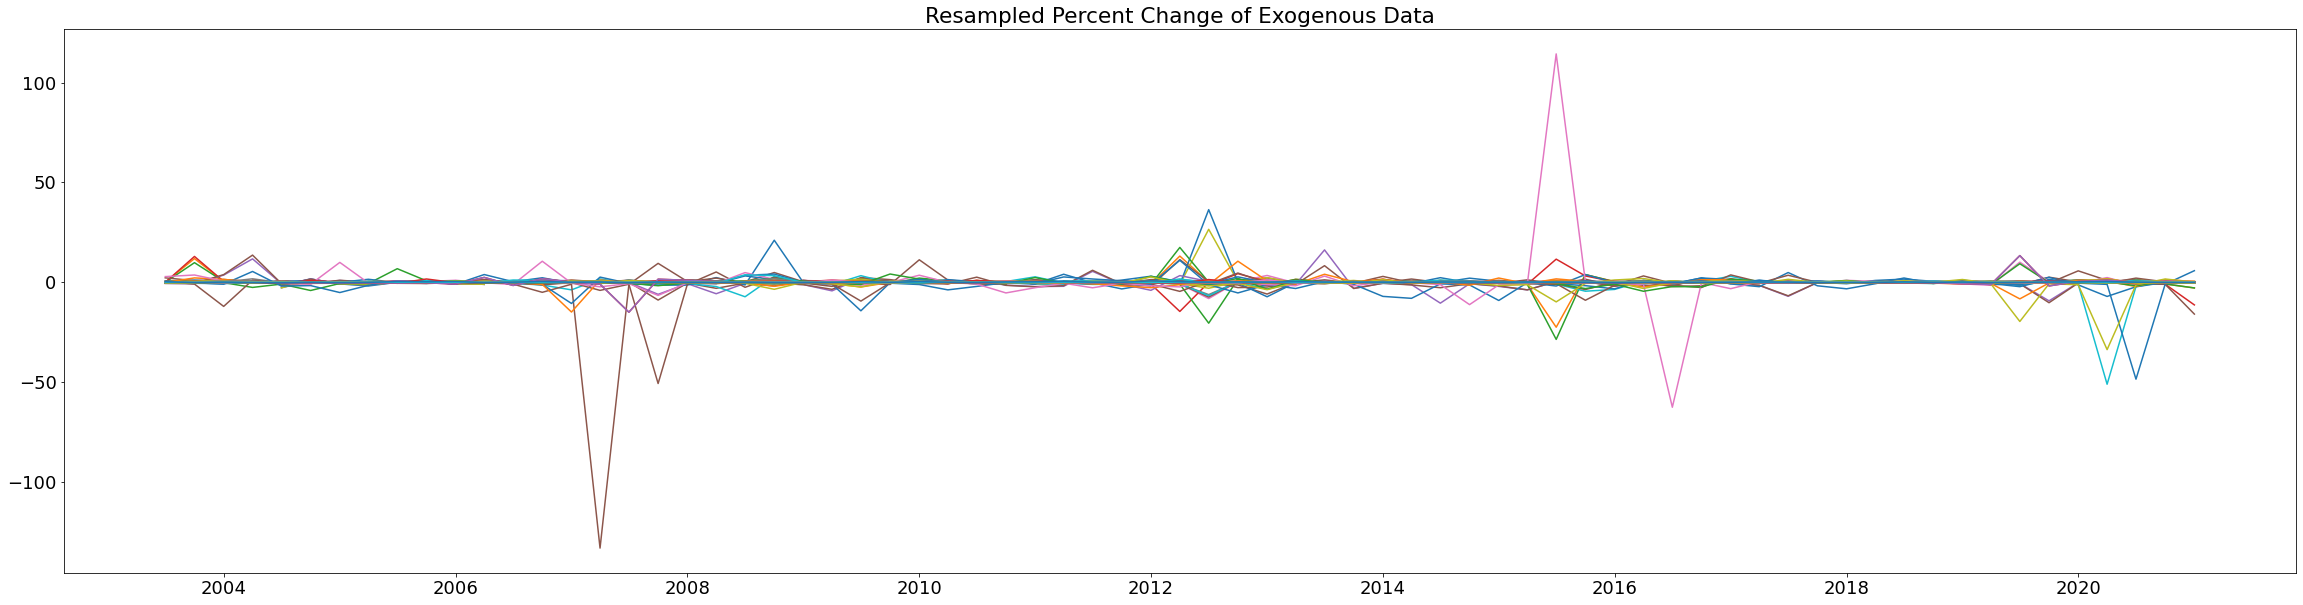

In [34]:
plt.plot(trgt_df)
plt.title('Resampled Percent Change of Exogenous Data')
plt.show()

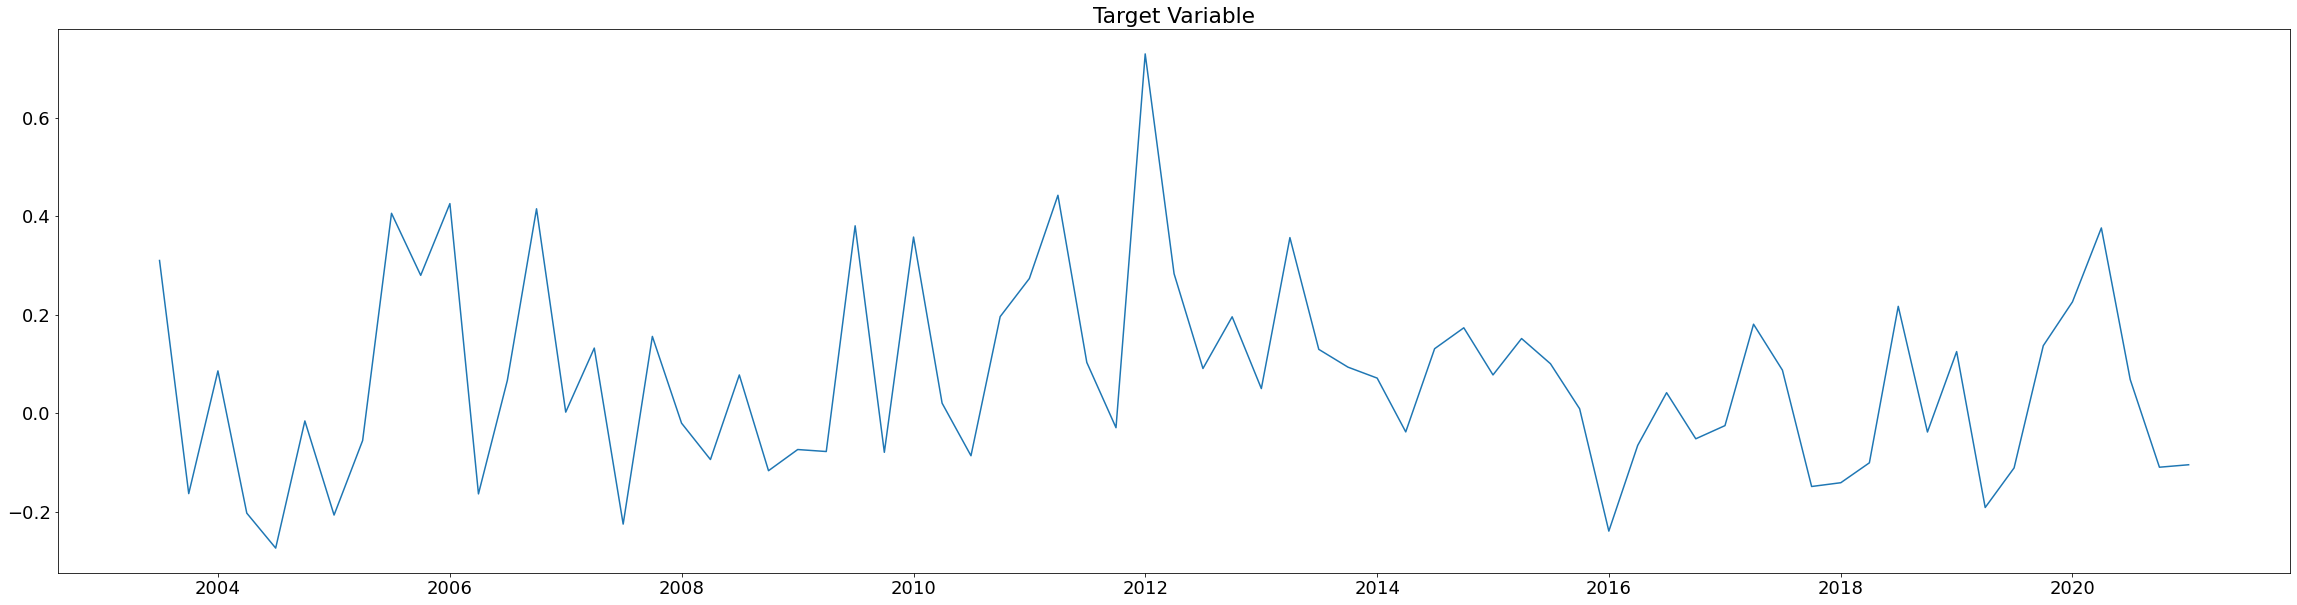

In [35]:
plt.plot(trgt_df['returns'])
plt.title('Target Variable')
plt.show()

In [36]:
##Dickey FUller test
#With the ADF test, the "null hypothesis" (the hypothesis that we either reject or fail to reject)
#is that the series follows a random walk. Therefore, a low p-value (say less than 5%) means we can 
#reject the null hypothesis that the series is a random walk.
## AUGMENTED DICKEY FULLER TEST
from statsmodels.tsa.stattools import adfuller
def dickey_fuller(resid):
    ls_df_ar = resid[~np.isnan(resid)]
    results = adfuller(np.array(ls_df_ar))
    #P-VALUE DF test
    print('The test statistic is: '+str(results[0]))
    print('The p-value of the test statististic is: ' + str(results[1]))
    if results[1] < 0.05:
        print("Because the P_value is < 0.05 we can claim this data array is stationary")
    else:
        print("Because the P_value is > 0.05 we can claim this data array is NOT stationary")

In [37]:
for i in trgt_df.columns:
    try:
        print(i)
        dickey_fuller(trgt_df[i])
    except:
        pass

commonStock
The test statistic is: -2.9511802562003857
The p-value of the test statististic is: 0.039711957534502886
Because the P_value is < 0.05 we can claim this data array is stationary
totalCashFromOperatingActivities
totalCurrentLiabilities
The test statistic is: -6.492565981963338
The p-value of the test statististic is: 1.2163785175808024e-08
Because the P_value is < 0.05 we can claim this data array is stationary
totalAssets
The test statistic is: -6.22591971347608
The p-value of the test statististic is: 5.089204107691639e-08
Because the P_value is < 0.05 we can claim this data array is stationary
totalLiab
The test statistic is: -6.849197108559201
The p-value of the test statististic is: 1.7115083855051906e-09
Because the P_value is < 0.05 we can claim this data array is stationary
totalStockholderEquity
The test statistic is: -7.92668254136274
The p-value of the test statististic is: 3.603087983508292e-12
Because the P_value is < 0.05 we can claim this data array is station

C:\Users\della\anaconda3\lib\site-packages\numpy\linalg\linalg.py:1872: RuntimeWarning: invalid value encountered in greater
  return count_nonzero(S > tol, axis=-1)



The p-value of the test statististic is: 5.188705828881599e-08
Because the P_value is < 0.05 we can claim this data array is stationary
production_% Worse
The test statistic is: -8.272504069280597
The p-value of the test statististic is: 4.75149906101583e-13
Because the P_value is < 0.05 we can claim this data array is stationary
production_Net
The test statistic is: -6.730594710613952
The p-value of the test statististic is: 3.3036513110921697e-09
Because the P_value is < 0.05 we can claim this data array is stationary
production
The test statistic is: -8.449364193494254
The p-value of the test statististic is: 1.678622112961382e-13
Because the P_value is < 0.05 we can claim this data array is stationary
deliveries_% Slower
The test statistic is: -7.718389994863769
The p-value of the test statististic is: 1.2109293971218086e-11
Because the P_value is < 0.05 we can claim this data array is stationary
deliveries_% Same
The test statistic is: -6.94572155741484
The p-value of the test st

In [38]:
#LIst of second transform  
list_fram = list(['totalAssets','totalLiab','totalLiab','totalStockholderEquity','book_value_pershare'
                ,'MED_CPI','Index_% Same','inventories_Net','exports_% Reporting.1','epsEstimate','employment_%Higher'
                ,'% Who Do Not Have Inventories or Do Not Measure','ebit','epsActual',
'grossProfit',
'operatingIncome',
'book_value_pershare',
'ROE',
'ROA',
'gross_profit_margin',
'operating_profit_margin',
'net_profit_margin',
'pre_tax_margin',
'index',
'CPI',
'cash_ratio',
'Value','M1V','M2V'])

for n in list_fram:
    f_dict['AAPL'][n+str('2nd_diff')] = f_dict['AAPL'][n].pct_change()
    print(n)
    
print('__________________________________________________________________________')
print('__________________________________________________________________________')
print('__________________________________________________________________________')
print('__________________________________________________________________________')
print('__________________________________________________________________________')
print('__________________________________________________________________________')
print('__________________________________________________________________________')


for i in f_dict['AAPL'].columns:
    try:
        dickey_fuller(f_dict['AAPL'][i])
        print(i)
    except:
        pass

totalAssets
totalLiab
totalLiab
totalStockholderEquity
book_value_pershare
MED_CPI
Index_% Same
inventories_Net
exports_% Reporting.1
epsEstimate
employment_%Higher
% Who Do Not Have Inventories or Do Not Measure
ebit
epsActual
grossProfit
operatingIncome
book_value_pershare
ROE
ROA
gross_profit_margin
operating_profit_margin
net_profit_margin
pre_tax_margin
index
CPI
cash_ratio
Value
M1V
M2V
__________________________________________________________________________
__________________________________________________________________________
__________________________________________________________________________
__________________________________________________________________________
__________________________________________________________________________
__________________________________________________________________________
__________________________________________________________________________
The test statistic is: 4.674408312147037
The p-value of the test statististic i

In [39]:
trgt_df.isnull().sum()

commonStock                         1
totalCashFromOperatingActivities    1
totalCurrentLiabilities             1
totalAssets                         1
totalLiab                           1
                                   ..
MED_CPI                             1
M2V                                 1
M1V                                 1
R_GDP                               1
returns                             1
Length: 131, dtype: int64

In [40]:
def dict_tr(df,yhat):
    df = df.clip(df.quantile(0.05),df.quantile(0.95), axis=1).dropna()
    plt.title("Stationary Data with Outliers Clipped")
    plt.plot(df)
    plt.show()
    df = df.replace([np.inf,-np.inf],np.nan).dropna()
    df = df.interpolate(method='linear')

    X = df.drop(yhat,axis=1)
    y =df[yhat]
    return(X,y)

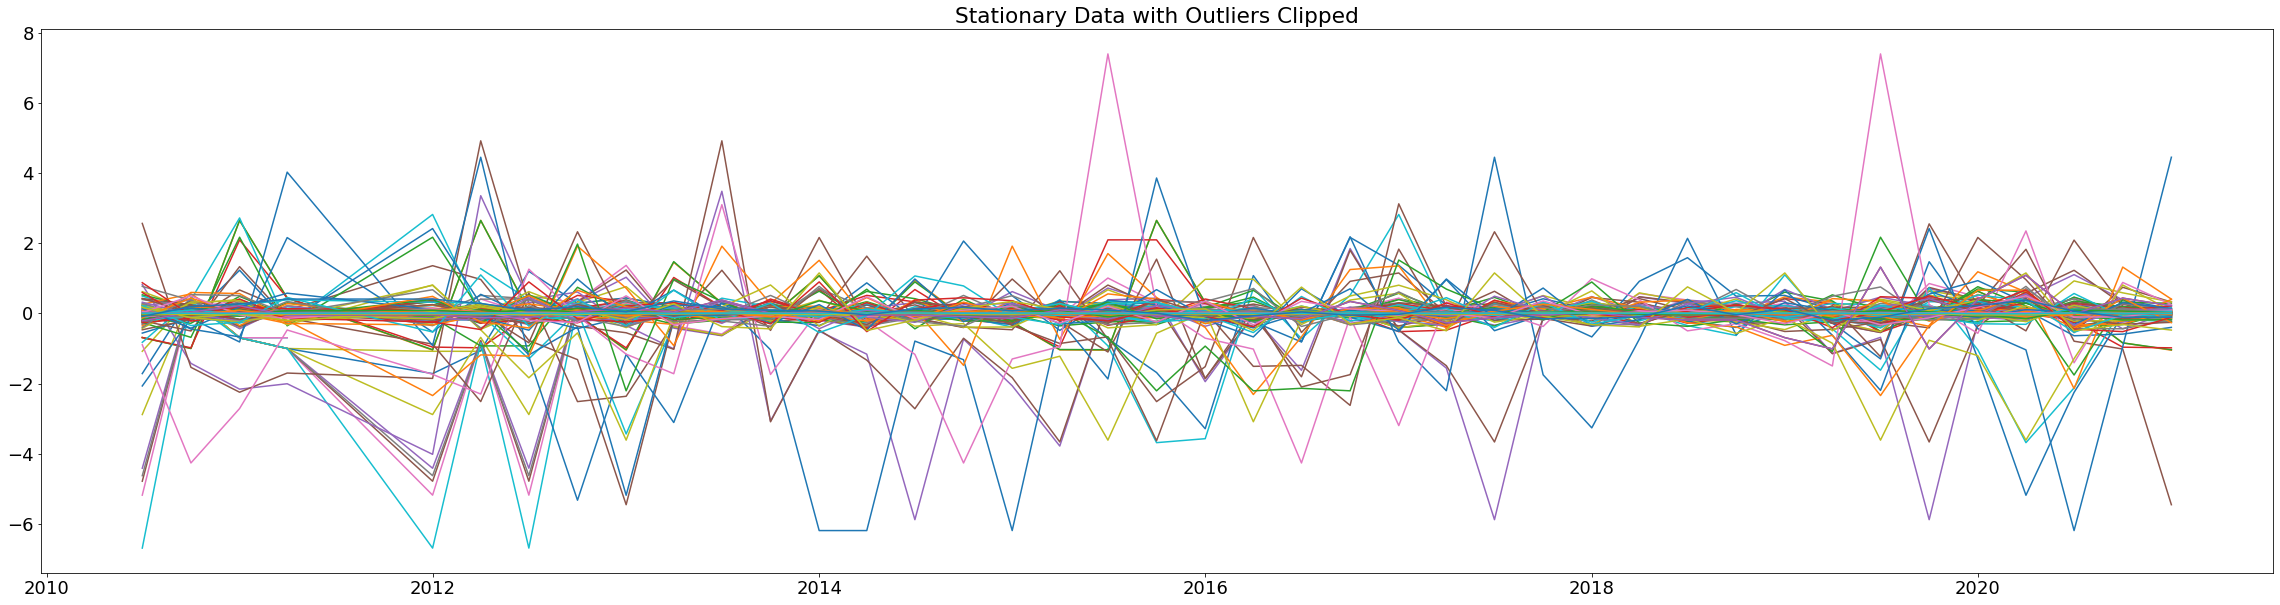

In [41]:
X,y = dict_tr(trgt_df,'returns')

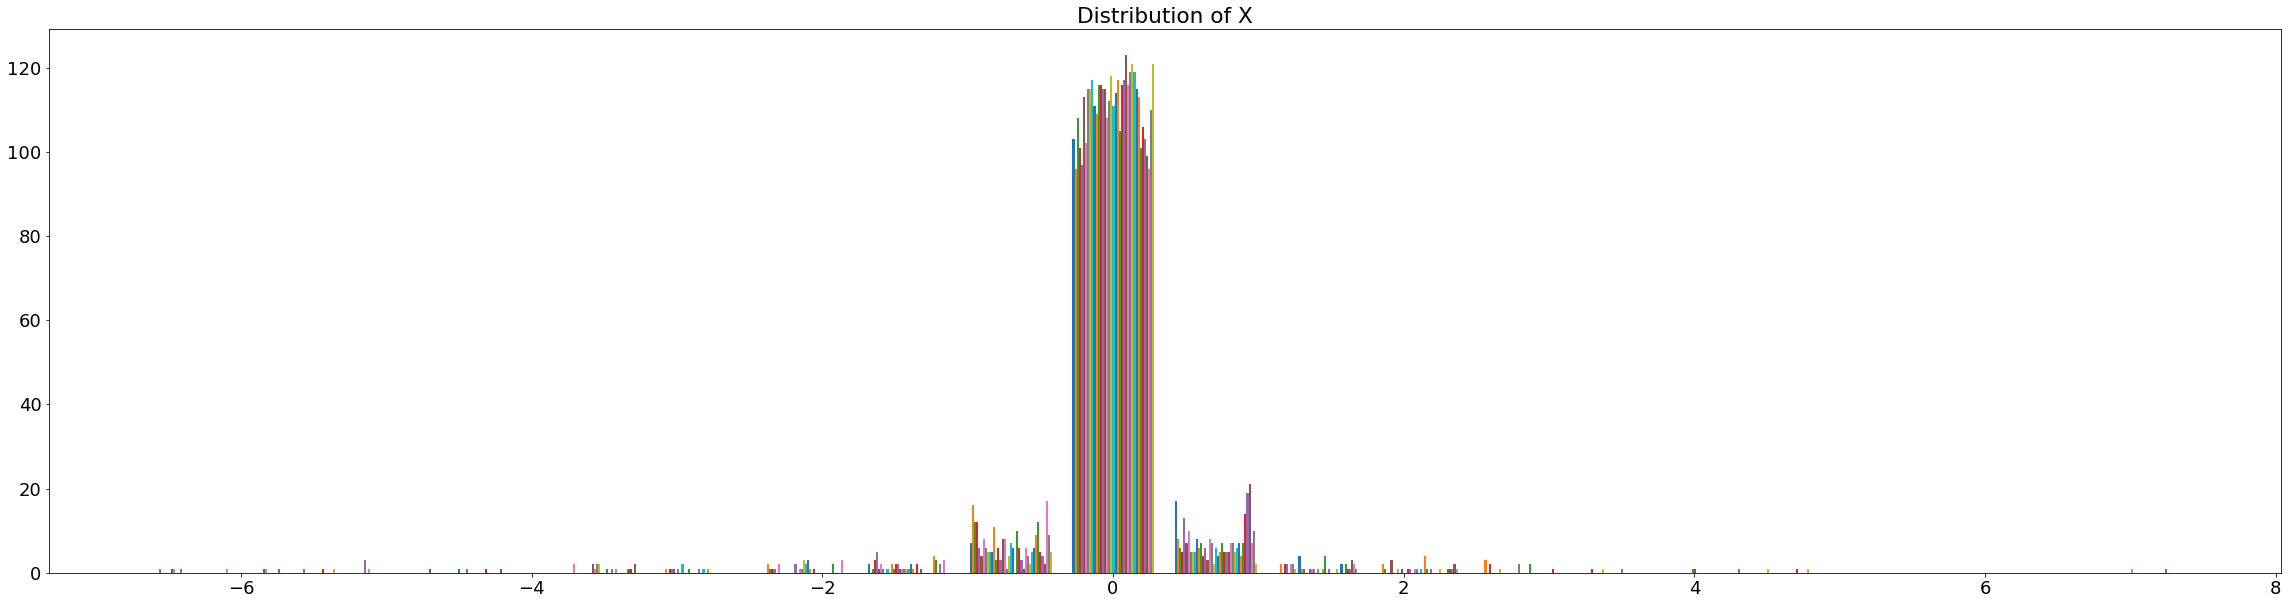

In [42]:
plt.hist(X, bins=20)
plt.title('Distribution of X')
plt.show()

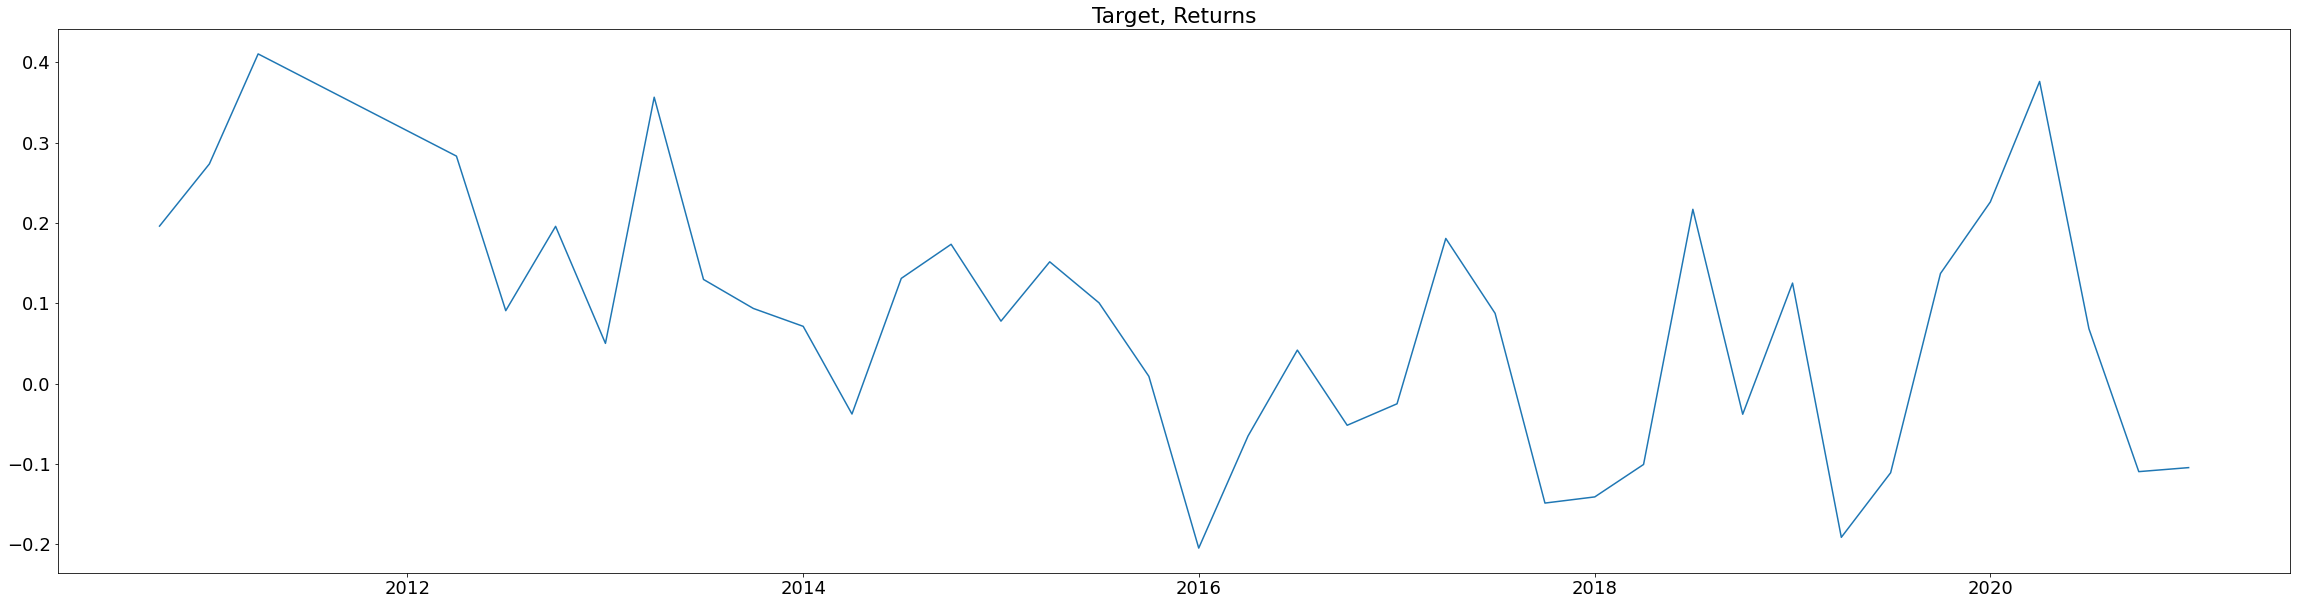

In [43]:
plt.title('Target, Returns')
plt.plot(y)
plt.show()

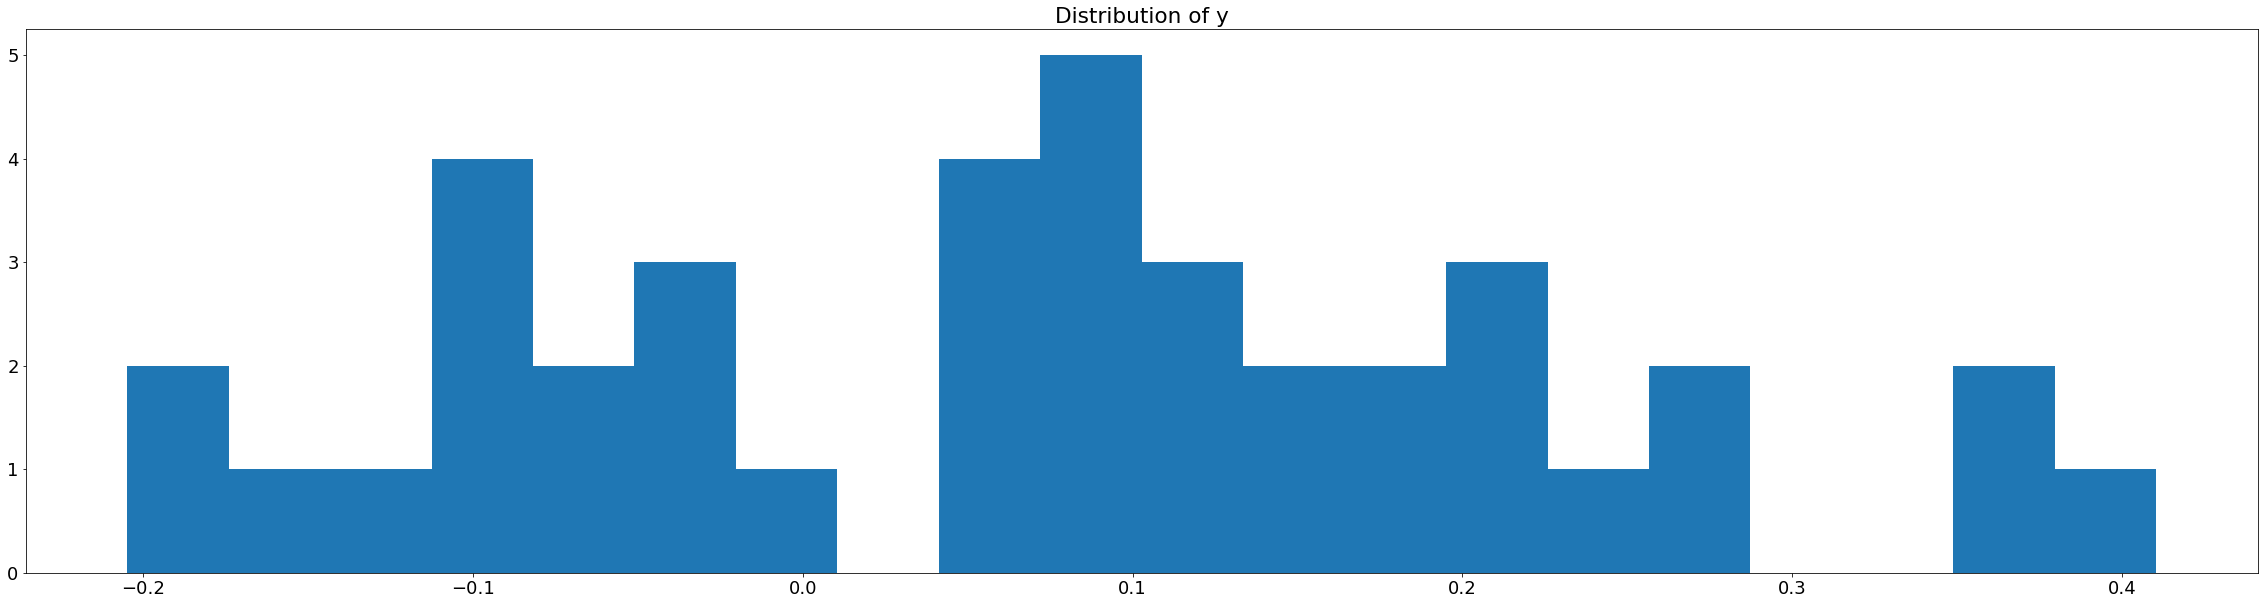

In [44]:
plt.hist(y, bins=20)
plt.title('Distribution of y')
plt.show()

In [45]:
# Algorithm that tests which variables are granger causal and transforms all statistically significant series into a multivariate supervised learning problem.
def gran_diff_transform(X,y,df,maxlag):
    yhat = pd.Series(y.shift(periods=-1))
    yhat.name = 'yhat'
    
    results={}
    for i in range(1,maxlag):
        r={}
        for a in X.columns:
            r[a] = uni_gr_test(X[a],yhat,i)
        results[i] = [a for a,v in r.items() if v <=0.05]

    y = y.dropna()
    df_dict = {}
    for i in range(1,maxlag):
        df1 = df[results[i]].dropna()
        df2 = df1.shift(periods=i)
        df_dict[i] = df2.dropna()
                     
    df_list = []
    for k,v in df_dict.items():
        df_list.append(v)
    df_c = pd.concat(df_list,axis=1)

    Granger_transformed_df = pd.concat([y,df_c,yhat],axis=1)
    Granger_transformed_df.index = Granger_transformed_df.index.shift(1)
    return(Granger_transformed_df)

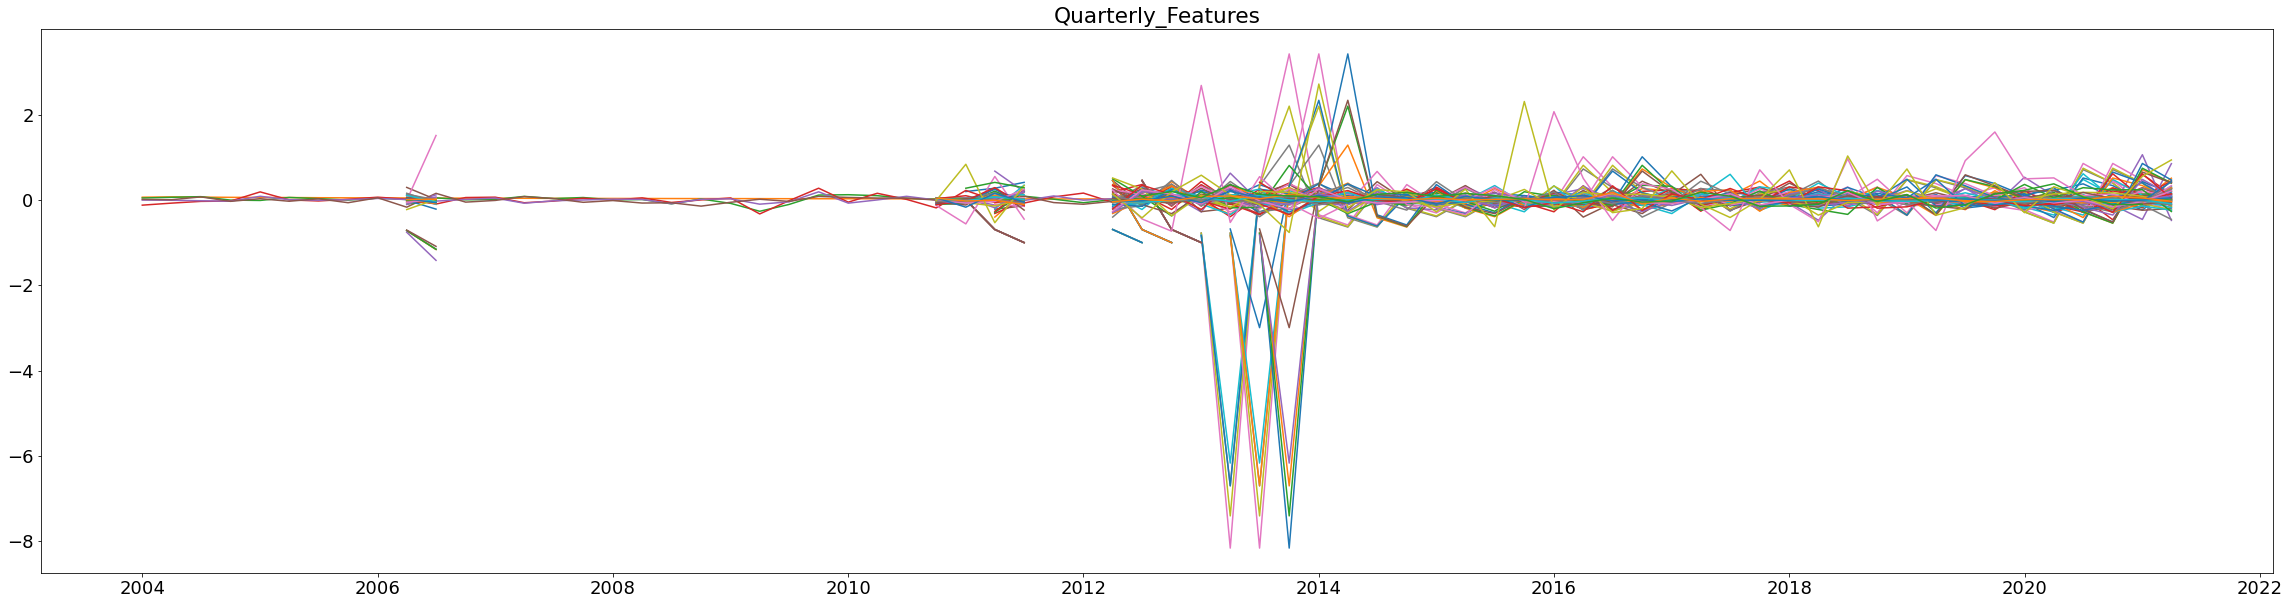

In [46]:
#before using Grange Causality test to find the causaul features lets create a series to supervised without granger causality and then use the test to identify the correct variables
gr_df = gran_diff_transform(X,y,trgt_df,5)

plt.plot(gr_df)
plt.title('Quarterly_Features')
plt.show()


In [47]:
# Very important for Final Live Forecast. Remove the last X-values and plug in to the final 
Exog = pd.DataFrame(gr_df.iloc[-1])
Exog = Exog.drop(['yhat'])
Exog.T

,returns,index,spy_close,production_% Same,exports_% Same,Index.1,netIncome,ROE,ROA,operating_profit_margin,...,exports_% Reporting,exports_% Greater,bus_act_%Higher,bus_act_%Same,new_ord_%Higher,new_ord_%Same,inventory_sentiment_%TooLow,imports_%Same,Index.1,Value
2021-04-01,-0.104731,0.012337,0.075144,0.133421,0.048377,0.06097,0.198214,0.45646,0.252161,-0.026074,...,0.020494,0.039348,0.098401,-0.049371,0.209146,-0.114932,0.935982,-0.08692,0.049357,-0.032211


In [48]:
Exog.T.shape

(1, 82)

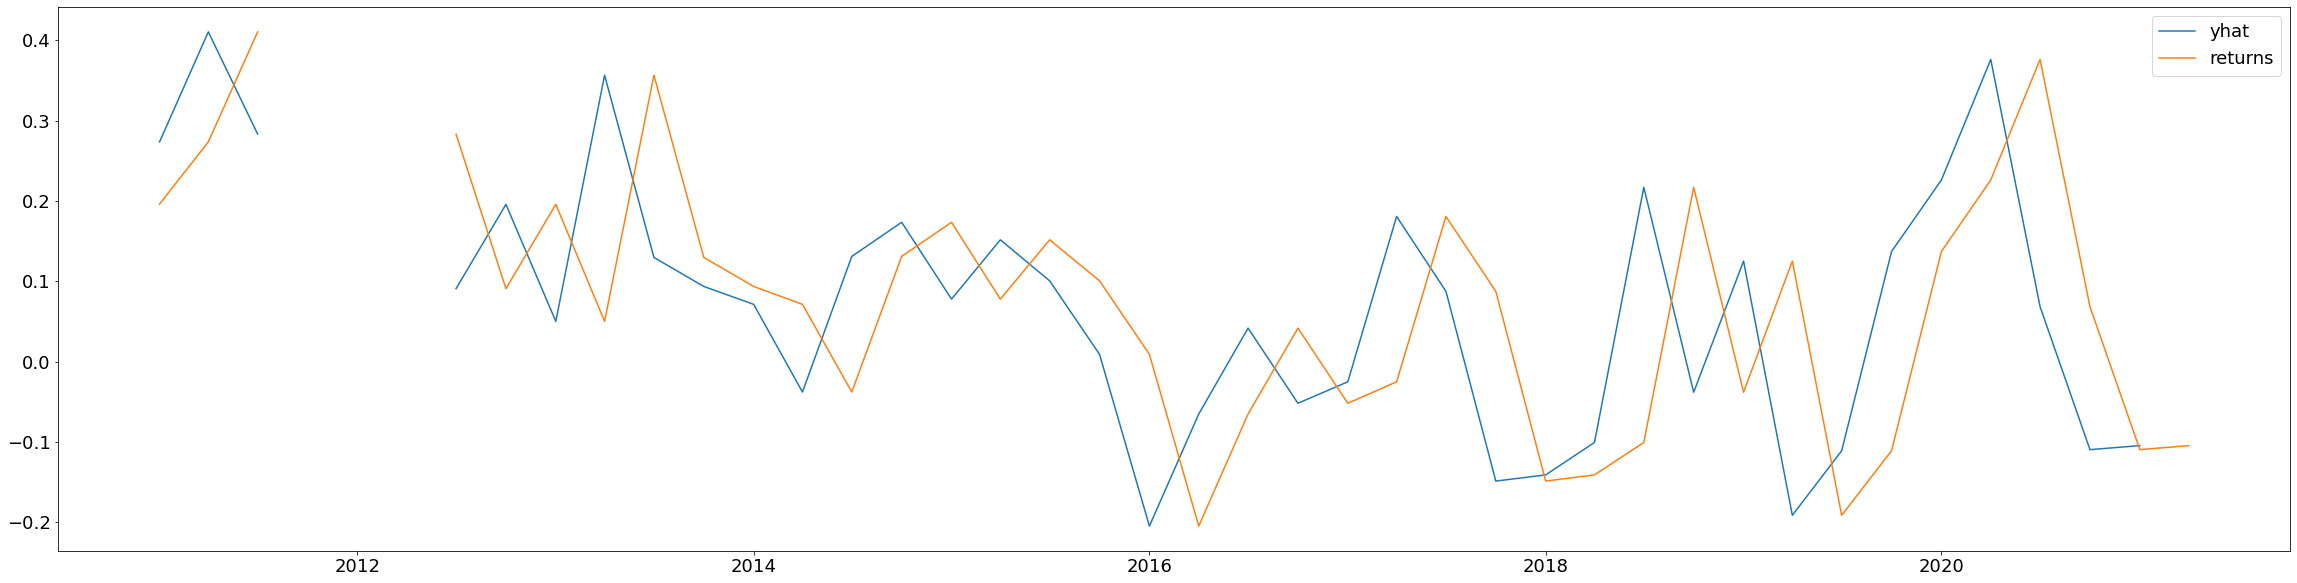

In [49]:
gr_df.columns
plt.plot(gr_df['yhat'],label='yhat')
plt.plot(gr_df['returns'],label='returns')
plt.legend()
plt.show()

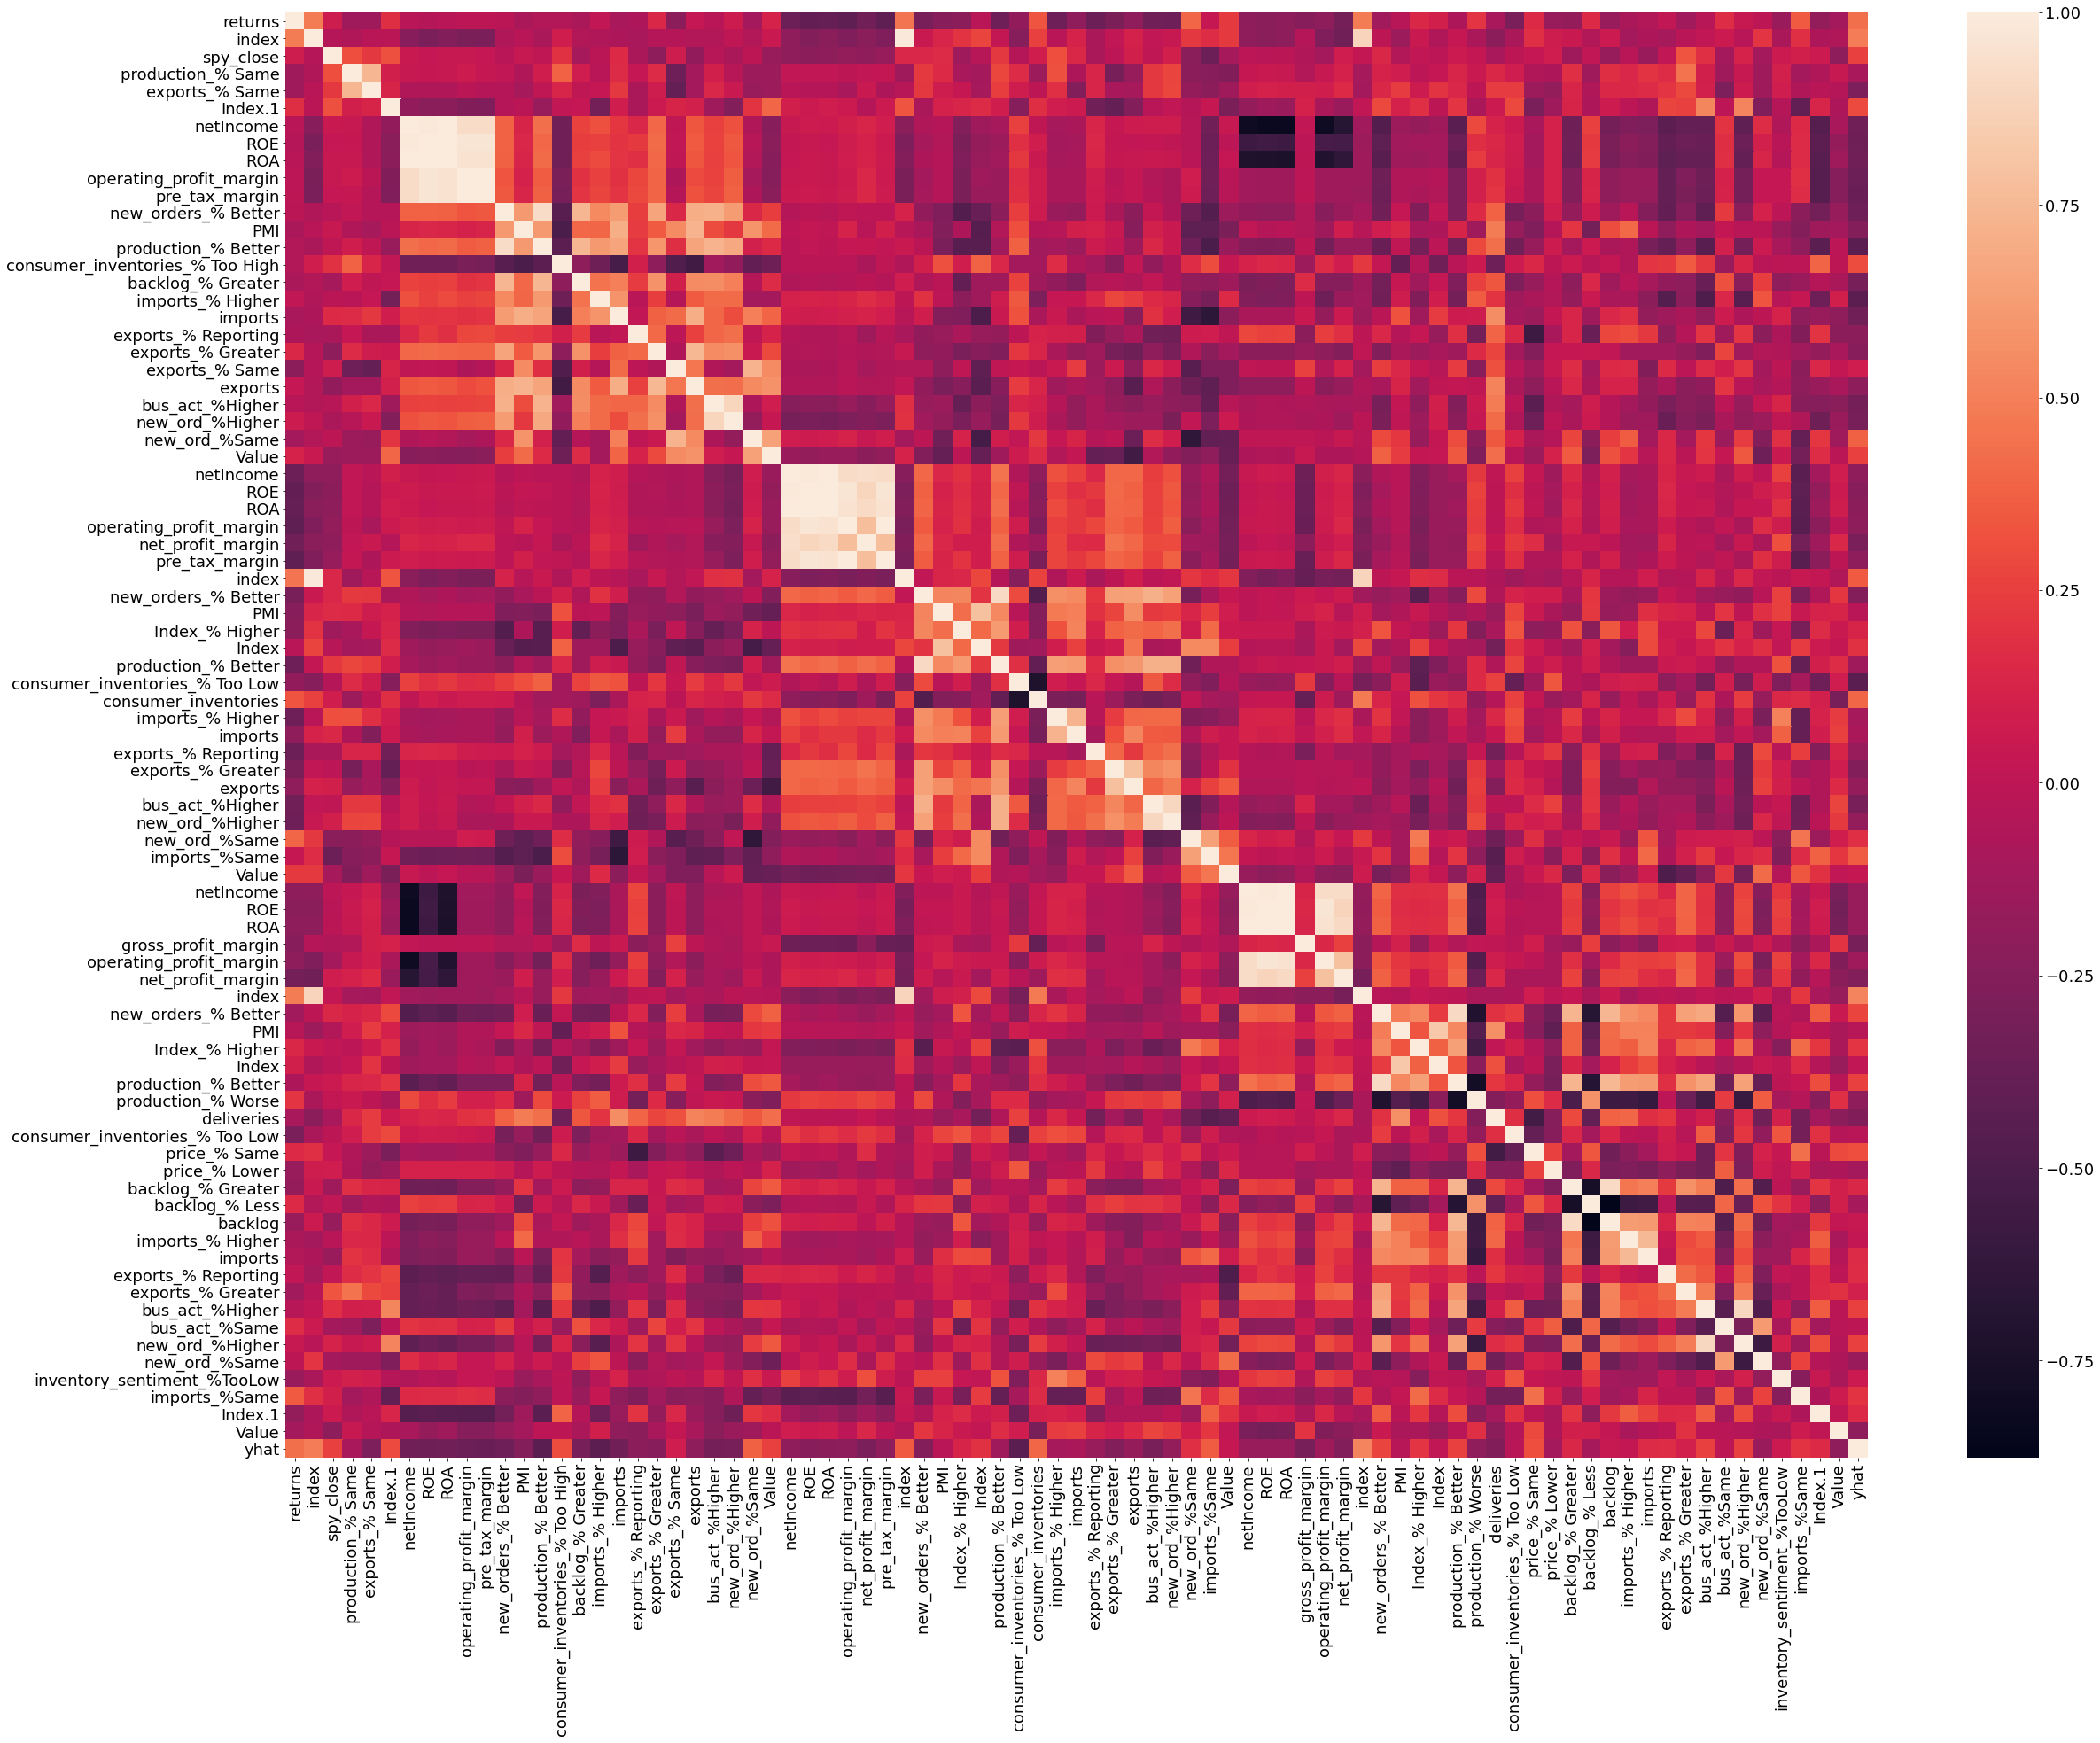

In [50]:
#Finished features graphed in a heatmap 
grf_corr = gr_df.corr()
plt.figure(figsize=(40,30))
sns.heatmap(grf_corr)
plt.show()

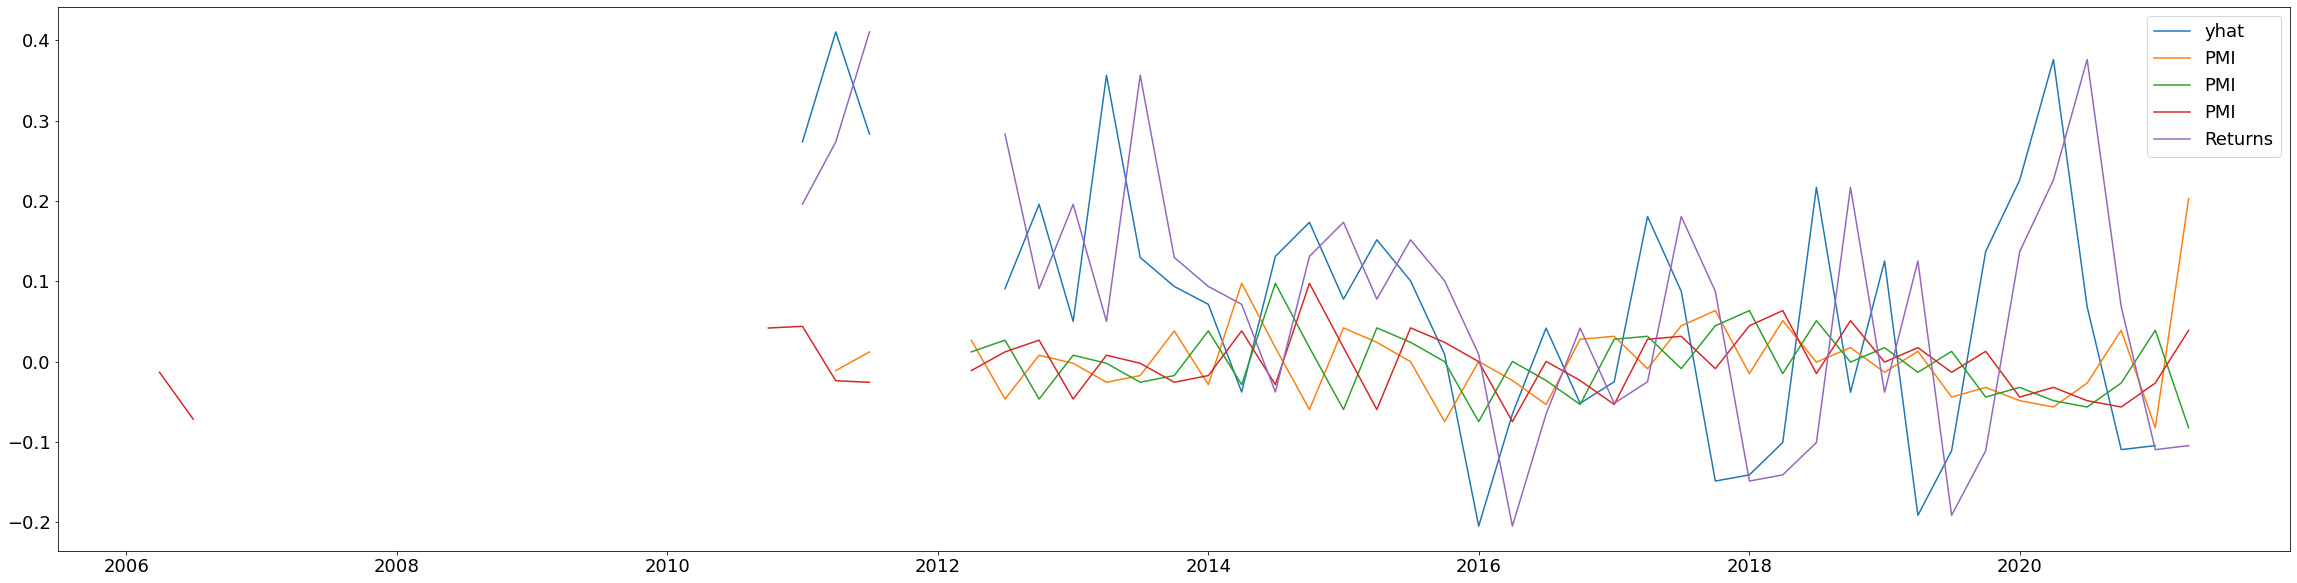

                yhat       PMI       PMI       PMI   returns
timeseries                                                  
2020-04-01  0.376087 -0.056680 -0.048761 -0.032219  0.226022
2020-07-01  0.068212 -0.026814 -0.056680 -0.048761  0.376087
2020-10-01 -0.109733  0.038858 -0.026814 -0.056680  0.068212
2021-01-01 -0.104731 -0.082613  0.038858 -0.026814 -0.109733
2021-04-01       NaN  0.202690 -0.082613  0.038858 -0.104731


In [51]:
#I want to see that yhat has been shifted back as the target variable for current period
plt.plot(gr_df['yhat'],label='yhat')
plt.plot(gr_df['PMI'],label='PMI')
plt.plot(gr_df['returns'],label='Returns')
plt.legend()
plt.show()
print(gr_df[['yhat','PMI','returns']].tail())

In [52]:
#Create EXOG for final live forecast test set !
gr_df =gr_df.replace([np.inf,-np.inf],np.nan).dropna()
X = gr_df.drop(['yhat'],axis=1)
y = gr_df['yhat']
y

timeseries
2012-07-01    0.090694
2013-07-01    0.129571
2013-10-01    0.093450
2014-01-01    0.071176
2014-04-01   -0.038008
2014-07-01    0.130869
2014-10-01    0.173338
2015-01-01    0.077663
2015-04-01    0.151523
2015-07-01    0.100428
2015-10-01    0.008902
2016-01-01   -0.204933
2016-04-01   -0.065384
2016-07-01    0.041577
2016-10-01   -0.052014
2017-01-01   -0.025267
2017-04-01    0.180606
2017-07-01    0.087362
2017-10-01   -0.148872
2018-01-01   -0.141199
2018-04-01   -0.100810
2018-07-01    0.216893
2018-10-01   -0.038273
2019-01-01    0.125040
2019-04-01   -0.191525
2019-07-01   -0.111148
2019-10-01    0.136957
2020-01-01    0.226022
2020-04-01    0.376087
2020-07-01    0.068212
2020-10-01   -0.109733
2021-01-01   -0.104731
Name: yhat, dtype: float64

In [53]:
X.isnull().sum().sort_values(ascending=False)

Value                  0
exports_% Same         0
bus_act_%Higher        0
new_ord_%Higher        0
new_ord_%Same          0
                      ..
net_profit_margin      0
index                  0
new_orders_% Better    0
PMI                    0
returns                0
Length: 82, dtype: int64

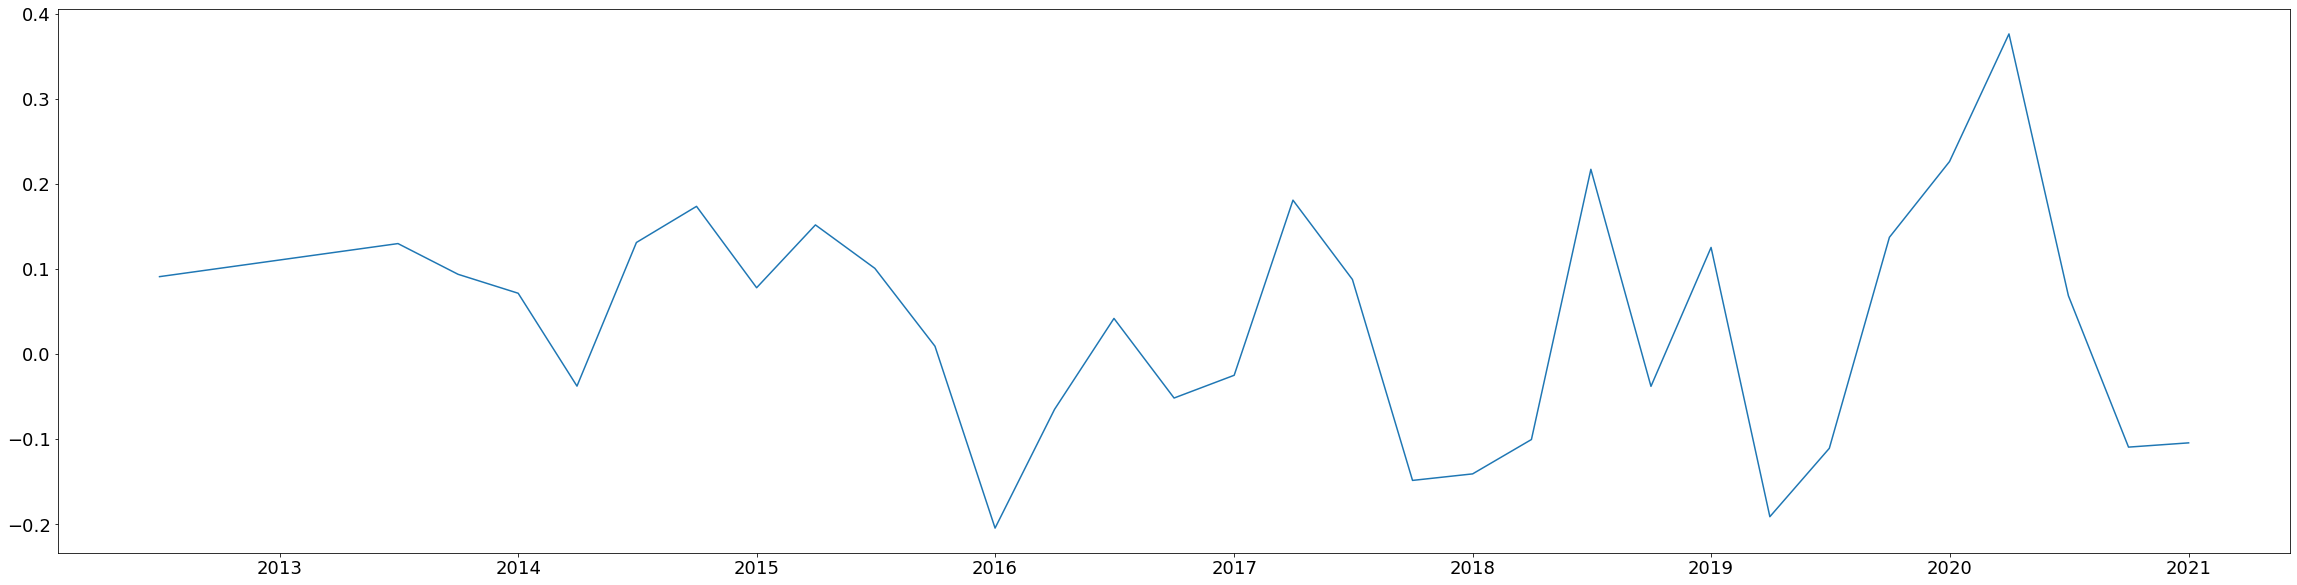

In [54]:
plt.plot(y)
plt.show()

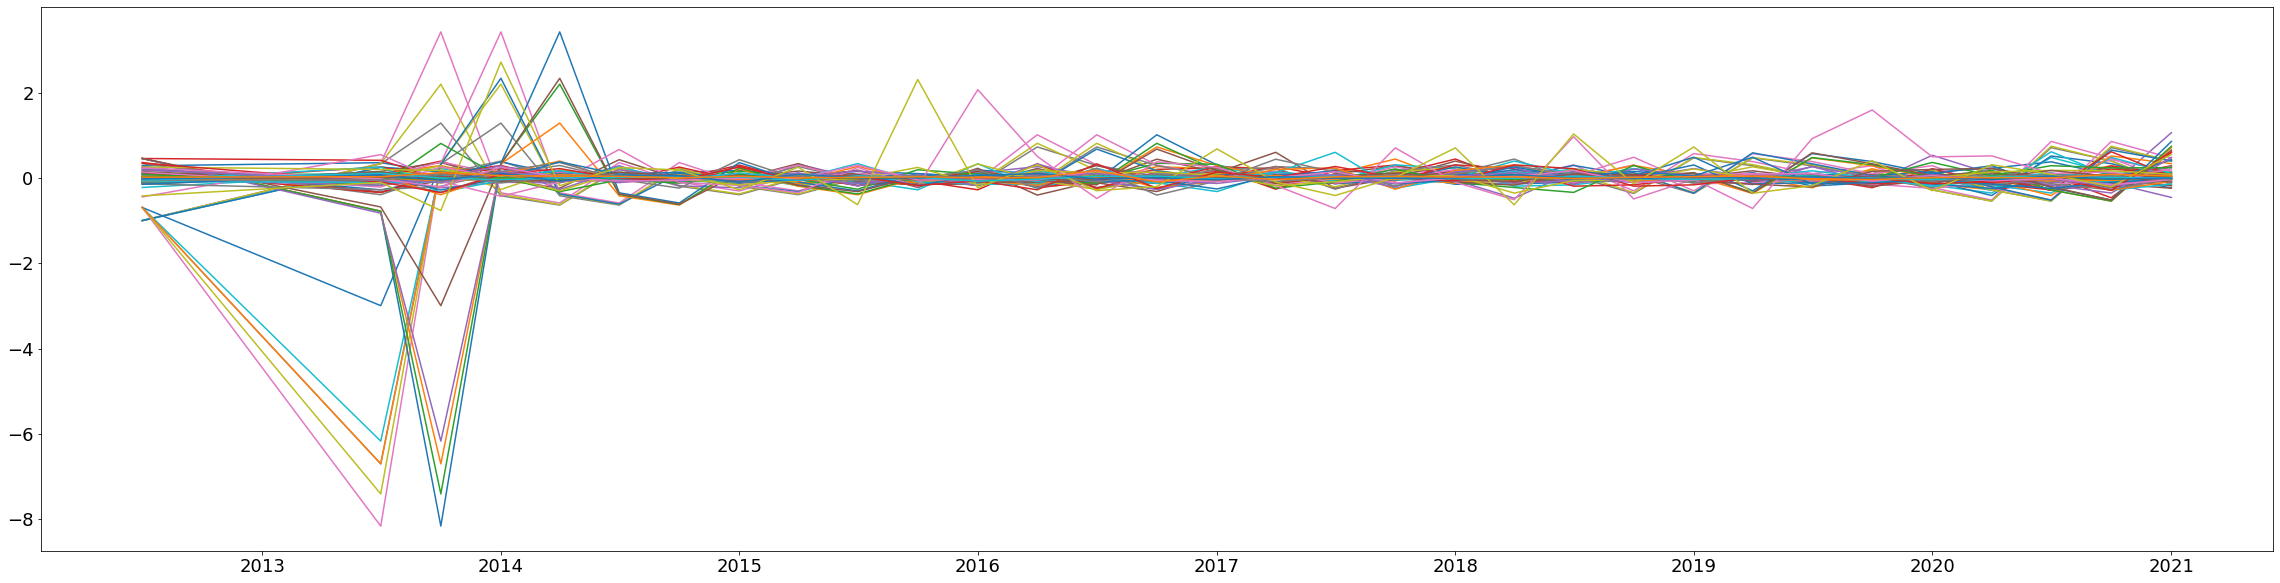

In [55]:
plt.plot(X)
plt.show()

In [56]:
print(Exog.T.shape)
print(X.shape)
print(y.shape)

(1, 82)
(32, 82)
(32,)


In [57]:
X.isnull().sum().sort_values(ascending=False).head(20)

Value                             0
exports_% Same                    0
bus_act_%Higher                   0
new_ord_%Higher                   0
new_ord_%Same                     0
Value                             0
netIncome                         0
ROE                               0
ROA                               0
operating_profit_margin           0
net_profit_margin                 0
pre_tax_margin                    0
index                             0
new_orders_% Better               0
PMI                               0
Index_% Higher                    0
Index                             0
production_% Better               0
consumer_inventories_% Too Low    0
exports                           0
dtype: int64

In [58]:
# FBprophet
from fbprophet import Prophet
from sklearn.metrics import mean_squared_error as mse
fb_df = pd.DataFrame(gr_df[['returns']].reset_index())
fb_df['ds'] = pd.to_datetime(fb_df['timeseries'])
fb_df['y'] = fb_df['returns']

ds = fb_df.drop(['timeseries','returns'],axis=1)

fbtss={}
tscv = TimeSeriesSplit(max_train_size=None, n_splits=5)
c=0
for train_index, test_index in (tscv.split(ds)):
    c+=1
    print("TRAIN:", train_index, "TEST:", test_index)
    y_train, y_test = ds.iloc[train_index], ds.iloc[test_index]
    fbtss[c] = [y_train,y_test]

TRAIN: [0 1 2 3 4 5 6] TEST: [ 7  8  9 10 11]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11] TEST: [12 13 14 15 16]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16] TEST: [17 18 19 20 21]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] TEST: [22 23 24 25 26]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26] TEST: [27 28 29 30 31]


INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:n_changepoints greater than number of observations. Using 4.
INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:n_changepoints greater than number of observations. Using 8.
INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:n_changepoints greater than number of observations. Using 12.
INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run p

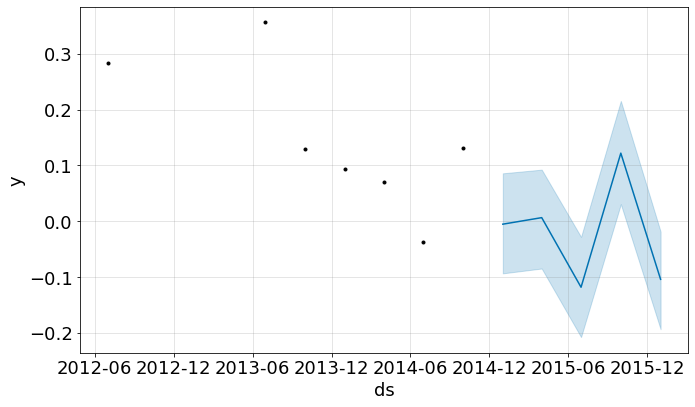

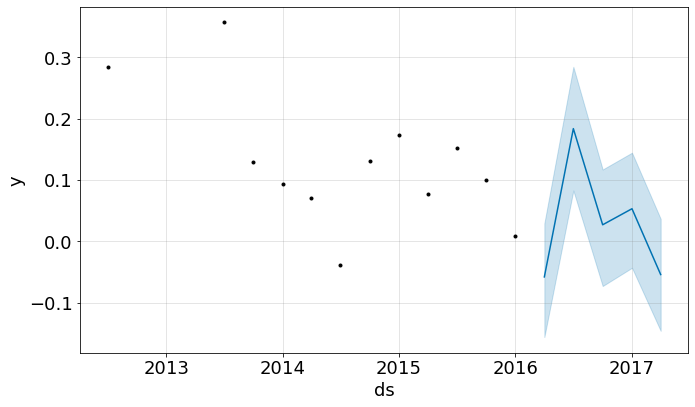

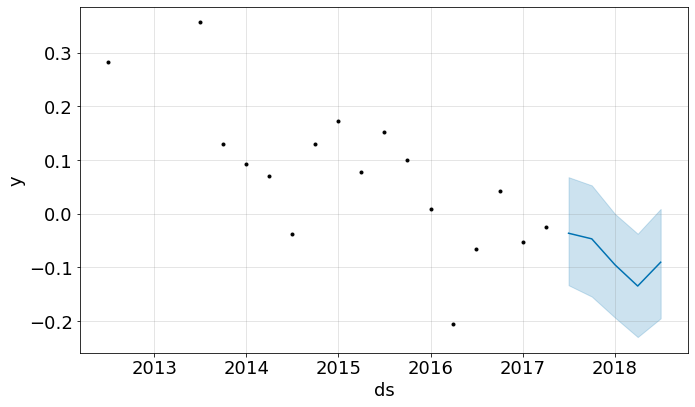

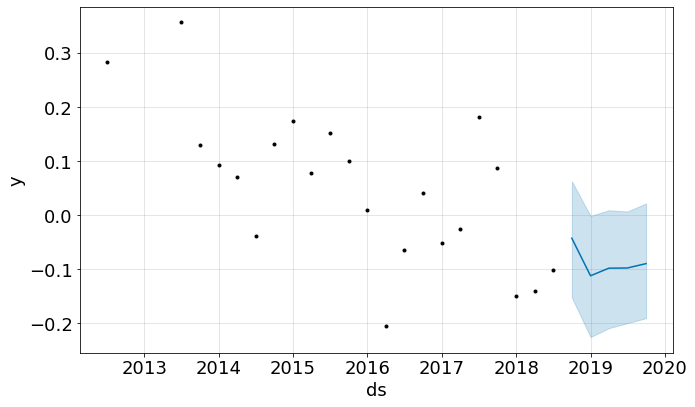

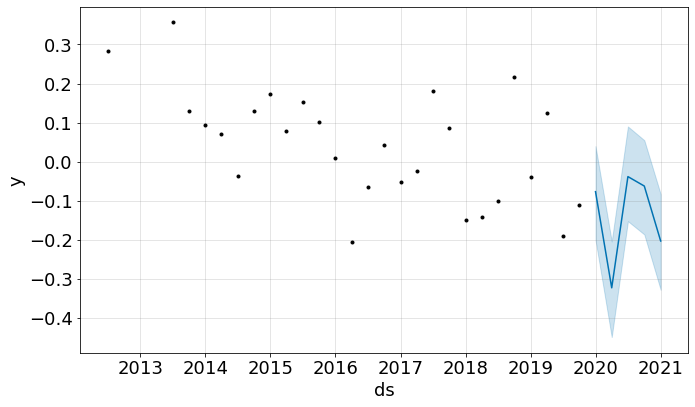

[0.024604162817815706, 0.019143008603636276, 0.013612130585351582, 0.026377292305636575, 0.10900160897805027]
The Mean Squared Error is:  0.038547640658098084


In [59]:
MSE=[]
for i in range(1,6):
    m = Prophet()
    m.fit(fbtss[i][0])
    forecast = m.predict(fbtss[i][1][['ds']])
    fig1 = m.plot(forecast)
    MSE.append(mse(fbtss[i][1][['y']],forecast[['yhat']]))
plt.show()
print(MSE)
avg_MSEx  = np.mean(MSE)
print('The Mean Squared Error is: ',avg_MSEx)

In [60]:
# For live forecasting we want to train on all available data only leaving the last value as the test for the model.
X_train = gr_df.drop(['yhat'], axis=1)
X_test = Exog.T
y_train = gr_df['yhat']

In [61]:
# We want X_test to be the last period of the avalable features for the final forecast.
X_train

,returns,index,spy_close,production_% Same,exports_% Same,Index.1,netIncome,ROE,ROA,operating_profit_margin,...,exports_% Reporting,exports_% Greater,bus_act_%Higher,bus_act_%Same,new_ord_%Higher,new_ord_%Same,inventory_sentiment_%TooLow,imports_%Same,Index.1,Value
timeseries,,,,,,,,,,,,,,,,,,,,,
2012-07-01,0.283132,0.020924,0.106468,-0.083525,-0.031362,0.197856,-1.000000,-1.000000e+00,-1.000000,-1.000000e+00,...,0.033203,0.345004,0.192171,-0.018649,0.234137,-0.057967,-0.420744,-0.051176,-0.021831,0.017419
2013-07-01,0.356457,0.018842,0.073424,-0.016367,0.043287,-0.077183,0.343726,3.290229e-01,0.337186,2.516754e-01,...,-0.012317,-0.095889,-0.065702,0.007487,-0.024134,-0.046056,-0.106252,0.109500,0.051721,0.028224
2013-10-01,0.129571,0.018796,0.068255,0.055325,0.001817,0.066146,3.419760,1.284555e+00,2.196105,1.483976e-01,...,-0.017200,-0.343259,-0.100513,0.040725,-0.213228,0.094340,-0.764045,-0.001738,-0.053415,0.122742
2014-01-01,0.093450,0.019045,0.046104,0.005114,0.043367,0.049923,-0.349078,-4.194110e-01,-0.385705,5.801002e-02,...,0.000207,0.081397,0.134311,-0.068331,0.255299,-0.119175,2.713710,-0.041284,0.107457,0.051070
2014-04-01,0.071176,0.018689,0.061204,-0.005653,-0.013040,-0.099631,-0.587971,-6.366517e-01,-0.624349,-8.232350e-03,...,-0.030115,0.217988,0.044416,-0.068390,0.010833,0.035547,-0.182085,0.000485,-0.077183,0.040185
2014-07-01,-0.038008,0.017916,0.042507,0.057531,-0.036374,0.083894,0.358815,2.118143e-01,0.236328,9.688706e-02,...,-0.000138,-0.013554,-0.086660,0.132516,-0.071369,0.067176,0.242284,0.010379,0.066146,0.037524
2014-10-01,0.130869,0.017460,0.040573,-0.059598,0.023751,0.004041,-0.098811,-1.940731e-01,-0.175299,-4.287907e-02,...,0.017761,-0.061069,-0.046680,0.050343,-0.056180,0.036481,0.186335,0.023192,0.049923,0.000823
2015-01-01,0.173338,0.017575,0.044685,-0.000191,0.031459,0.002651,-0.305605,-3.937299e-01,-0.375854,-1.218939e-01,...,0.012581,0.254065,0.003264,-0.089869,-0.010119,-0.111025,-0.280105,0.022474,-0.099631,0.039148
2015-04-01,0.077663,0.017408,0.021810,0.018296,-0.002435,0.055234,0.100160,-7.049114e-03,0.011368,1.914686e-02,...,0.000401,-0.063050,0.017318,0.003031,-0.012647,0.043377,0.251386,-0.058832,0.083894,0.000424


In [62]:
fb_df = pd.DataFrame(gr_df[['returns']].reset_index())
fb_df['ds'] = pd.to_datetime(fb_df['timeseries'])
fb_df['y'] = fb_df['returns']
ds = fb_df.drop(['timeseries','returns'],axis=1)

In [63]:
train = ds
test = m.make_future_dataframe(periods=90)
test.tail()

,ds
112,2019-12-26
113,2019-12-27
114,2019-12-28
115,2019-12-29
116,2019-12-30


INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:n_changepoints greater than number of observations. Using 24.


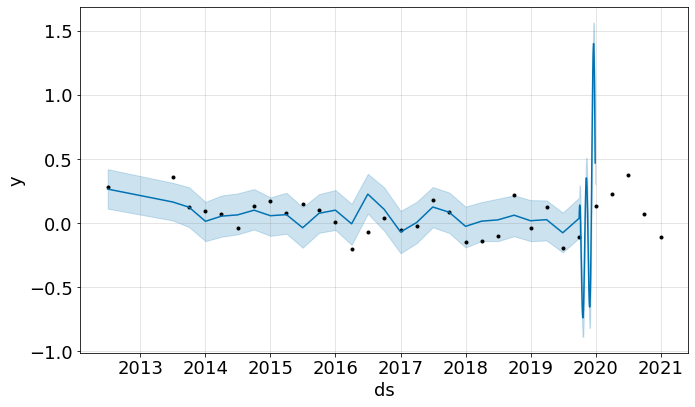

7.424624812596504


In [85]:
m = Prophet()
m.fit(train)
forecast = m.predict(test)
fig1 = m.plot(forecast)
plt.show()

print(forecast['yhat'].sum())

In [65]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

tssq={}
tscv = TimeSeriesSplit(max_train_size=None, n_splits=5)
c=0
for train_index, test_index in (tscv.split(gr_df)):
    c+=1
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    tssq[c] = [X_train,X_test,y_train,y_test]

TRAIN: [0 1 2 3 4 5 6] TEST: [ 7  8  9 10 11]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11] TEST: [12 13 14 15 16]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16] TEST: [17 18 19 20 21]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] TEST: [22 23 24 25 26]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26] TEST: [27 28 29 30 31]


[0.022012296328531, 0.00805669181387421, 0.04183422352763731, 0.025460794604429828, 0.025640850222050475]
The Mean Squared Error is:  0.024600971299304563


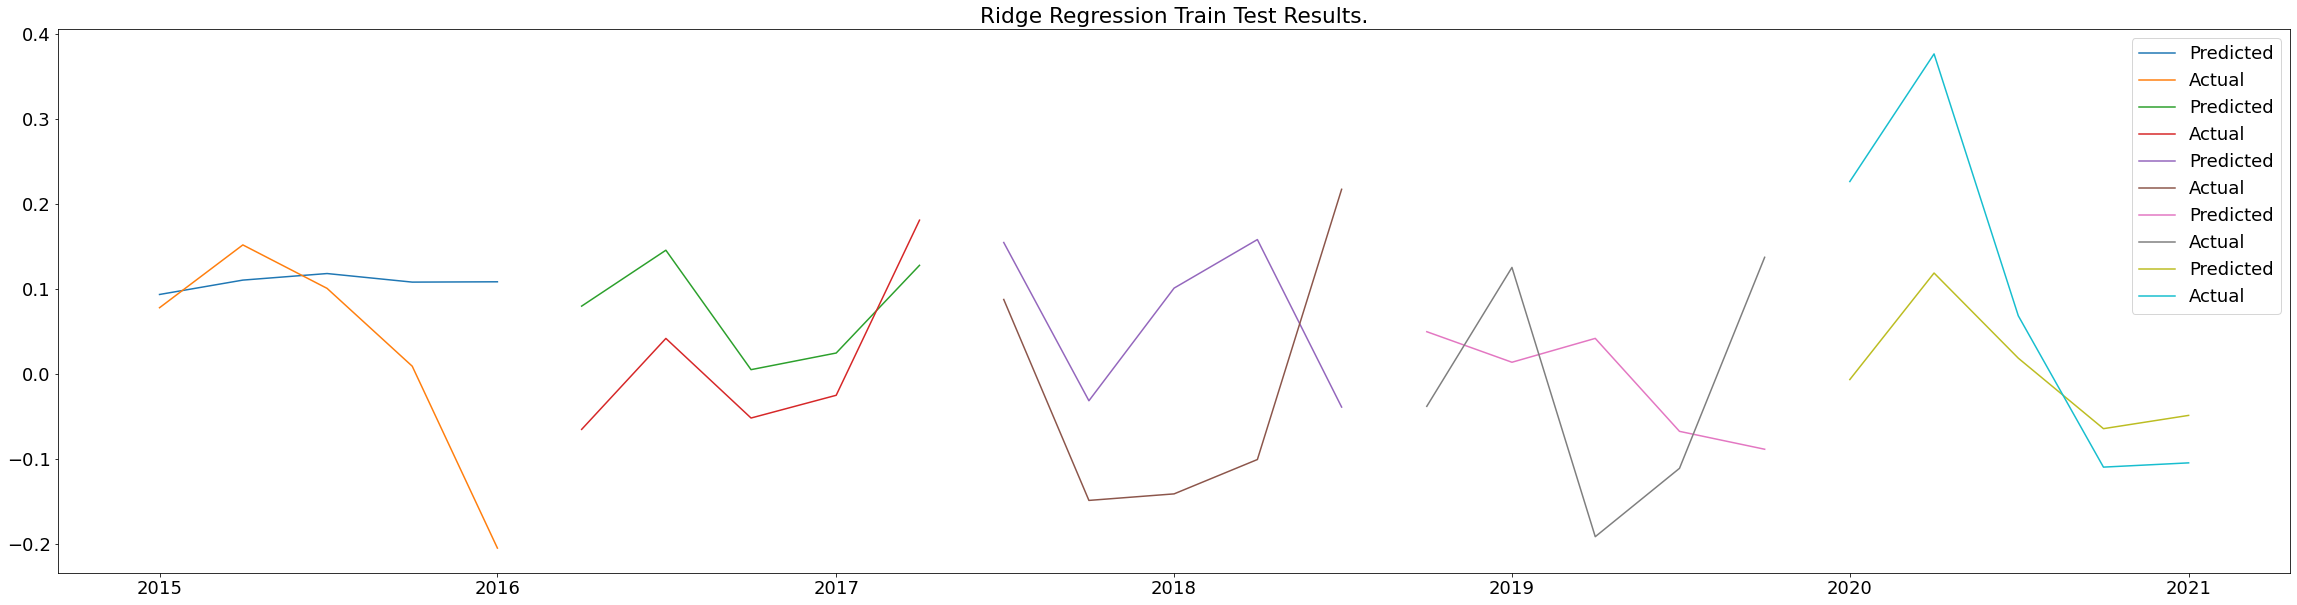

In [66]:
from sklearn.linear_model import Ridge
rdg = Ridge(alpha=1.0)
MSEr=[]
for i in range(1,6):
    rdg.fit(tssq[i][0],tssq[i][2])
    ridge_p = rdg.predict(tssq[i][1])
    pred_df = pd.Series(ridge_p,index=tssq[i][1].index)
    
    # Catch the error
    MSEr.append(mse(tssq[i][3],pred_df))
    
    # Plot the result
    plt.plot(pred_df, label='Predicted')
    plt.plot(tssq[i][3],label='Actual')
plt.legend() 
plt.title('Ridge Regression Train Test Results.')    
plt.show

print(MSEr)
avg_MSEx = np.mean(MSEr)
print('The Mean Squared Error is: ',avg_MSEx)

In [67]:
print(tssq[5][1].index)
print(Exog.T)
tssq[5][1] = pd.concat([tssq[5][1],Exog.T])
tssq[5][1]

DatetimeIndex(['2020-01-01', '2020-04-01', '2020-07-01', '2020-10-01',
               '2021-01-01'],
              dtype='datetime64[ns]', name='timeseries', freq=None)
             returns     index  spy_close  production_% Same  exports_% Same  \
2021-04-01 -0.104731  0.012337   0.075144           0.133421        0.048377   

            Index.1  netIncome      ROE       ROA  operating_profit_margin  \
2021-04-01  0.06097   0.198214  0.45646  0.252161                -0.026074   

            ...  exports_% Reporting  exports_% Greater  bus_act_%Higher  \
2021-04-01  ...             0.020494           0.039348         0.098401   

            bus_act_%Same  new_ord_%Higher  new_ord_%Same  \
2021-04-01      -0.049371         0.209146      -0.114932   

            inventory_sentiment_%TooLow  imports_%Same   Index.1     Value  
2021-04-01                     0.935982       -0.08692  0.049357 -0.032211  

[1 rows x 82 columns]


,returns,index,spy_close,production_% Same,exports_% Same,Index.1,netIncome,ROE,ROA,operating_profit_margin,...,exports_% Reporting,exports_% Greater,bus_act_%Higher,bus_act_%Same,new_ord_%Higher,new_ord_%Same,inventory_sentiment_%TooLow,imports_%Same,Index.1,Value
2020-01-01,0.136957,0.013036,0.031127,0.073935,-0.065333,-0.028567,-0.229389,-0.281294,-0.282256,-0.171915,...,0.003185,-0.134497,0.071033,-0.097611,0.054477,-0.074783,-0.299320,-0.038821,0.013665,0.009718
2020-04-01,0.226022,0.012970,0.046988,-0.070193,-0.022229,-0.005486,-0.518646,-0.542277,-0.543947,-0.354613,...,-0.030473,-0.093739,-0.053946,0.000386,-0.070677,0.026316,0.308531,0.034498,-0.043748,0.009061
2020-07-01,0.376087,0.012604,-0.004454,0.051436,0.031084,0.049357,0.853886,0.708790,0.742135,0.480134,...,0.019488,0.017631,-0.034022,0.174057,-0.006126,0.072039,0.083257,0.026317,0.042859,-0.001263
2020-10-01,0.068212,0.012348,-0.034817,-0.465703,-0.235528,-0.223423,0.466183,0.397773,0.395035,0.106505,...,-0.027713,-0.292941,-0.188192,0.033676,-0.163090,0.035388,-0.211152,0.008571,-0.028567,0.083352
2021-01-01,-0.109733,0.012393,0.137213,0.595617,0.269592,-0.033172,-0.099364,-0.161489,-0.148779,0.100726,...,0.007077,0.612403,-0.007429,-0.096979,-0.037185,-0.030049,0.551282,-0.003237,-0.005486,0.046208
2021-04-01,-0.104731,0.012337,0.075144,0.133421,0.048377,0.060970,0.198214,0.456460,0.252161,-0.026074,...,0.020494,0.039348,0.098401,-0.049371,0.209146,-0.114932,0.935982,-0.086920,0.049357,-0.032211


In [68]:
# For live forecasting we want to train on all available data only leaving the last value as the test for the model.
X_train = gr_df.drop(['yhat'], axis=1)
X_test = Exog.T
y_train = gr_df['yhat']

In [69]:
# We want X_test to be the last period of the avalable features for the final forecast.
X_train

,returns,index,spy_close,production_% Same,exports_% Same,Index.1,netIncome,ROE,ROA,operating_profit_margin,...,exports_% Reporting,exports_% Greater,bus_act_%Higher,bus_act_%Same,new_ord_%Higher,new_ord_%Same,inventory_sentiment_%TooLow,imports_%Same,Index.1,Value
timeseries,,,,,,,,,,,,,,,,,,,,,
2012-07-01,0.283132,0.020924,0.106468,-0.083525,-0.031362,0.197856,-1.000000,-1.000000e+00,-1.000000,-1.000000e+00,...,0.033203,0.345004,0.192171,-0.018649,0.234137,-0.057967,-0.420744,-0.051176,-0.021831,0.017419
2013-07-01,0.356457,0.018842,0.073424,-0.016367,0.043287,-0.077183,0.343726,3.290229e-01,0.337186,2.516754e-01,...,-0.012317,-0.095889,-0.065702,0.007487,-0.024134,-0.046056,-0.106252,0.109500,0.051721,0.028224
2013-10-01,0.129571,0.018796,0.068255,0.055325,0.001817,0.066146,3.419760,1.284555e+00,2.196105,1.483976e-01,...,-0.017200,-0.343259,-0.100513,0.040725,-0.213228,0.094340,-0.764045,-0.001738,-0.053415,0.122742
2014-01-01,0.093450,0.019045,0.046104,0.005114,0.043367,0.049923,-0.349078,-4.194110e-01,-0.385705,5.801002e-02,...,0.000207,0.081397,0.134311,-0.068331,0.255299,-0.119175,2.713710,-0.041284,0.107457,0.051070
2014-04-01,0.071176,0.018689,0.061204,-0.005653,-0.013040,-0.099631,-0.587971,-6.366517e-01,-0.624349,-8.232350e-03,...,-0.030115,0.217988,0.044416,-0.068390,0.010833,0.035547,-0.182085,0.000485,-0.077183,0.040185
2014-07-01,-0.038008,0.017916,0.042507,0.057531,-0.036374,0.083894,0.358815,2.118143e-01,0.236328,9.688706e-02,...,-0.000138,-0.013554,-0.086660,0.132516,-0.071369,0.067176,0.242284,0.010379,0.066146,0.037524
2014-10-01,0.130869,0.017460,0.040573,-0.059598,0.023751,0.004041,-0.098811,-1.940731e-01,-0.175299,-4.287907e-02,...,0.017761,-0.061069,-0.046680,0.050343,-0.056180,0.036481,0.186335,0.023192,0.049923,0.000823
2015-01-01,0.173338,0.017575,0.044685,-0.000191,0.031459,0.002651,-0.305605,-3.937299e-01,-0.375854,-1.218939e-01,...,0.012581,0.254065,0.003264,-0.089869,-0.010119,-0.111025,-0.280105,0.022474,-0.099631,0.039148
2015-04-01,0.077663,0.017408,0.021810,0.018296,-0.002435,0.055234,0.100160,-7.049114e-03,0.011368,1.914686e-02,...,0.000401,-0.063050,0.017318,0.003031,-0.012647,0.043377,0.251386,-0.058832,0.083894,0.000424


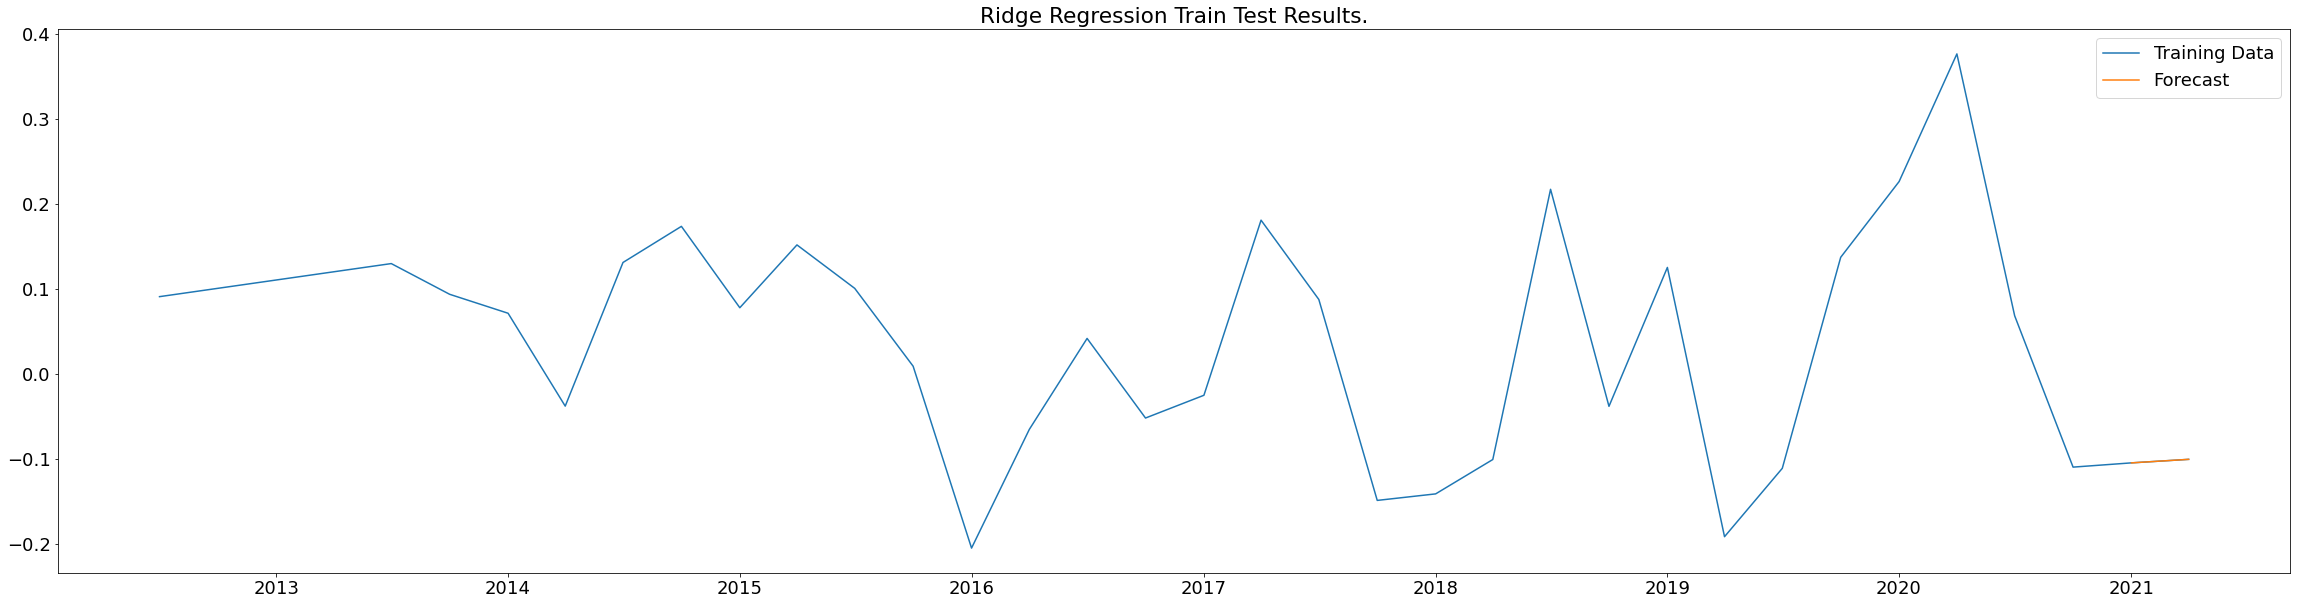

2021-04-01   -0.100601
dtype: float64


In [70]:
R_LIVE = Ridge(alpha=1.5)
R_LIVE.fit(X_train,y_train)
ridge_pred = R_LIVE.predict(X_test)
predict_df = pd.Series(ridge_pred,index=X_test.index)

plt_df = pd.concat([y_train,predict_df],axis=0)
plt.plot(plt_df, label='Training Data')
plt.plot(plt_df.iloc[-2:],label='Forecast')
plt.legend() 
plt.title('Ridge Regression Train Test Results.')    
plt.show()
print(predict_df)

In [71]:
tssq={}
tscv = TimeSeriesSplit(max_train_size=None, n_splits=5)
c=0
for train_index, test_index in (tscv.split(gr_df)):
    c+=1
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    tssq[c] = [X_train,X_test,y_train,y_test]

TRAIN: [0 1 2 3 4 5 6] TEST: [ 7  8  9 10 11]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11] TEST: [12 13 14 15 16]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16] TEST: [17 18 19 20 21]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] TEST: [22 23 24 25 26]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26] TEST: [27 28 29 30 31]


In [72]:
# USE THe Auto Arima Function Below to specify the parameters for the SARIMAX model below
#Be warned as this is not nearly as good as using ACF and PACF to manually calculate the parameters.
from pmdarima.arima import auto_arima
arima_model=auto_arima(y_train, 
exogenous= X_train,
start_p=0, start_q=0,
seasonal=True,
m=4,
max_p=7, max_q=7, 
start_P=0,max_P=3,
start_Q=0,max_Q=3,
trace=True, 
error_action='ignore', 
suppress_warnings=True, 
stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=-405.190, Time=3.08 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=-400.451, Time=2.04 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=-400.799, Time=1.84 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=-407.164, Time=0.76 sec
 ARIMA(0,0,0)(1,0,0)[4] intercept   : AIC=-403.079, Time=2.05 sec
 ARIMA(0,0,0)(0,0,1)[4] intercept   : AIC=-402.915, Time=1.39 sec
 ARIMA(0,0,0)(1,0,1)[4] intercept   : AIC=-395.768, Time=1.92 sec
 ARIMA(1,0,0)(0,0,0)[4] intercept   : AIC=-402.594, Time=1.44 sec
 ARIMA(0,0,1)(0,0,0)[4] intercept   : AIC=-403.104, Time=1.58 sec
 ARIMA(1,0,1)(0,0,0)[4] intercept   : AIC=-400.992, Time=1.21 sec

Best model:  ARIMA(0,0,0)(0,0,0)[4]          
Total fit time: 17.338 seconds


In [73]:
import sklearn.metrics

C:\Users\della\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:216: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\della\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:216: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\della\anaconda3\lib\site-packages\statsmodels\base\model.py:567: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn("Maximum Likelihood optimization failed to converge. "
C:\Users\della\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:580: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`

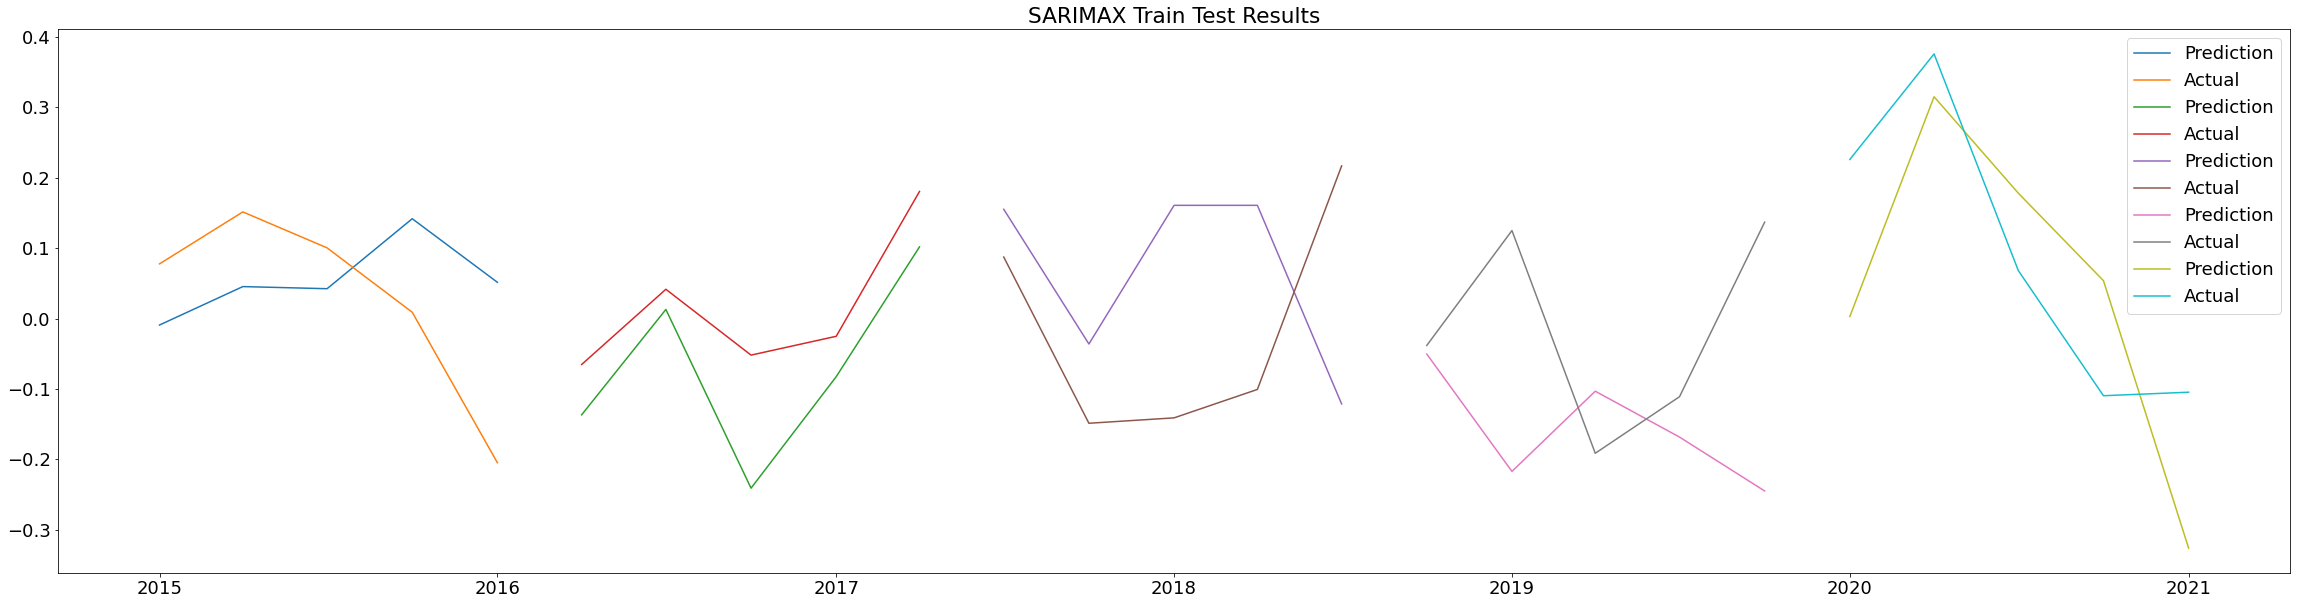

[0.021118974251041683, 0.010240216708372673, 0.05829043158170981, 0.054876641692012784, 0.028291919852730017]
The Mean Squared Error is:  0.03456363681717339


In [74]:
#Testing the model without forecast.

MSEs=[]
for i in range(1,6):
    mod = sm.tsa.statespace.SARIMAX(tssq[i][2],tssq[i][0],order=(0,0,0),seasonal_order=(0,0,0,4))
    ##FIT##
    results = mod.fit()
    #Prediction##
    train_size=len(tssq[i][0])
    test_size=len(tssq[i][1])
    predictions= results.predict(start=train_size, end=(train_size+test_size-1), exog=tssq[i][1])
    predictions.index=tssq[i][1].index
    #catch the error
    MSEs.append(mse(tssq[i][3],predictions))
    #Plot
    plt.title('SARIMAX Train Test Results')
    plt.plot(predictions, label='Prediction')
    plt.plot(tssq[i][3], label = 'Actual')
    plt.legend()
plt.show()



print(MSEs)
avg_MSEx = np.mean(MSEs)
print('The Mean Squared Error is: ',avg_MSEx)

In [75]:
tssq={}
tscv = TimeSeriesSplit(max_train_size=None, n_splits=5)
c=0
for train_index, test_index in (tscv.split(gr_df)):
    c+=1
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    tssq[c] = [X_train,X_test,y_train,y_test]

TRAIN: [0 1 2 3 4 5 6] TEST: [ 7  8  9 10 11]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11] TEST: [12 13 14 15 16]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16] TEST: [17 18 19 20 21]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] TEST: [22 23 24 25 26]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26] TEST: [27 28 29 30 31]


In [76]:
# For live forecasting we want to train on all available data only leaving the last value as the test for the model.
X_train = gr_df.drop(['yhat'], axis=1)
X_test = Exog.T
y_train = gr_df['yhat']

In [77]:
# We want X_test to be the last period of the avalable features for the final forecast.
X_train

,returns,index,spy_close,production_% Same,exports_% Same,Index.1,netIncome,ROE,ROA,operating_profit_margin,...,exports_% Reporting,exports_% Greater,bus_act_%Higher,bus_act_%Same,new_ord_%Higher,new_ord_%Same,inventory_sentiment_%TooLow,imports_%Same,Index.1,Value
timeseries,,,,,,,,,,,,,,,,,,,,,
2012-07-01,0.283132,0.020924,0.106468,-0.083525,-0.031362,0.197856,-1.000000,-1.000000e+00,-1.000000,-1.000000e+00,...,0.033203,0.345004,0.192171,-0.018649,0.234137,-0.057967,-0.420744,-0.051176,-0.021831,0.017419
2013-07-01,0.356457,0.018842,0.073424,-0.016367,0.043287,-0.077183,0.343726,3.290229e-01,0.337186,2.516754e-01,...,-0.012317,-0.095889,-0.065702,0.007487,-0.024134,-0.046056,-0.106252,0.109500,0.051721,0.028224
2013-10-01,0.129571,0.018796,0.068255,0.055325,0.001817,0.066146,3.419760,1.284555e+00,2.196105,1.483976e-01,...,-0.017200,-0.343259,-0.100513,0.040725,-0.213228,0.094340,-0.764045,-0.001738,-0.053415,0.122742
2014-01-01,0.093450,0.019045,0.046104,0.005114,0.043367,0.049923,-0.349078,-4.194110e-01,-0.385705,5.801002e-02,...,0.000207,0.081397,0.134311,-0.068331,0.255299,-0.119175,2.713710,-0.041284,0.107457,0.051070
2014-04-01,0.071176,0.018689,0.061204,-0.005653,-0.013040,-0.099631,-0.587971,-6.366517e-01,-0.624349,-8.232350e-03,...,-0.030115,0.217988,0.044416,-0.068390,0.010833,0.035547,-0.182085,0.000485,-0.077183,0.040185
2014-07-01,-0.038008,0.017916,0.042507,0.057531,-0.036374,0.083894,0.358815,2.118143e-01,0.236328,9.688706e-02,...,-0.000138,-0.013554,-0.086660,0.132516,-0.071369,0.067176,0.242284,0.010379,0.066146,0.037524
2014-10-01,0.130869,0.017460,0.040573,-0.059598,0.023751,0.004041,-0.098811,-1.940731e-01,-0.175299,-4.287907e-02,...,0.017761,-0.061069,-0.046680,0.050343,-0.056180,0.036481,0.186335,0.023192,0.049923,0.000823
2015-01-01,0.173338,0.017575,0.044685,-0.000191,0.031459,0.002651,-0.305605,-3.937299e-01,-0.375854,-1.218939e-01,...,0.012581,0.254065,0.003264,-0.089869,-0.010119,-0.111025,-0.280105,0.022474,-0.099631,0.039148
2015-04-01,0.077663,0.017408,0.021810,0.018296,-0.002435,0.055234,0.100160,-7.049114e-03,0.011368,1.914686e-02,...,0.000401,-0.063050,0.017318,0.003031,-0.012647,0.043377,0.251386,-0.058832,0.083894,0.000424


C:\Users\della\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:216: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\della\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:216: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\della\anaconda3\lib\site-packages\statsmodels\base\model.py:567: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn("Maximum Likelihood optimization failed to converge. "
C:\Users\della\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:580: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`

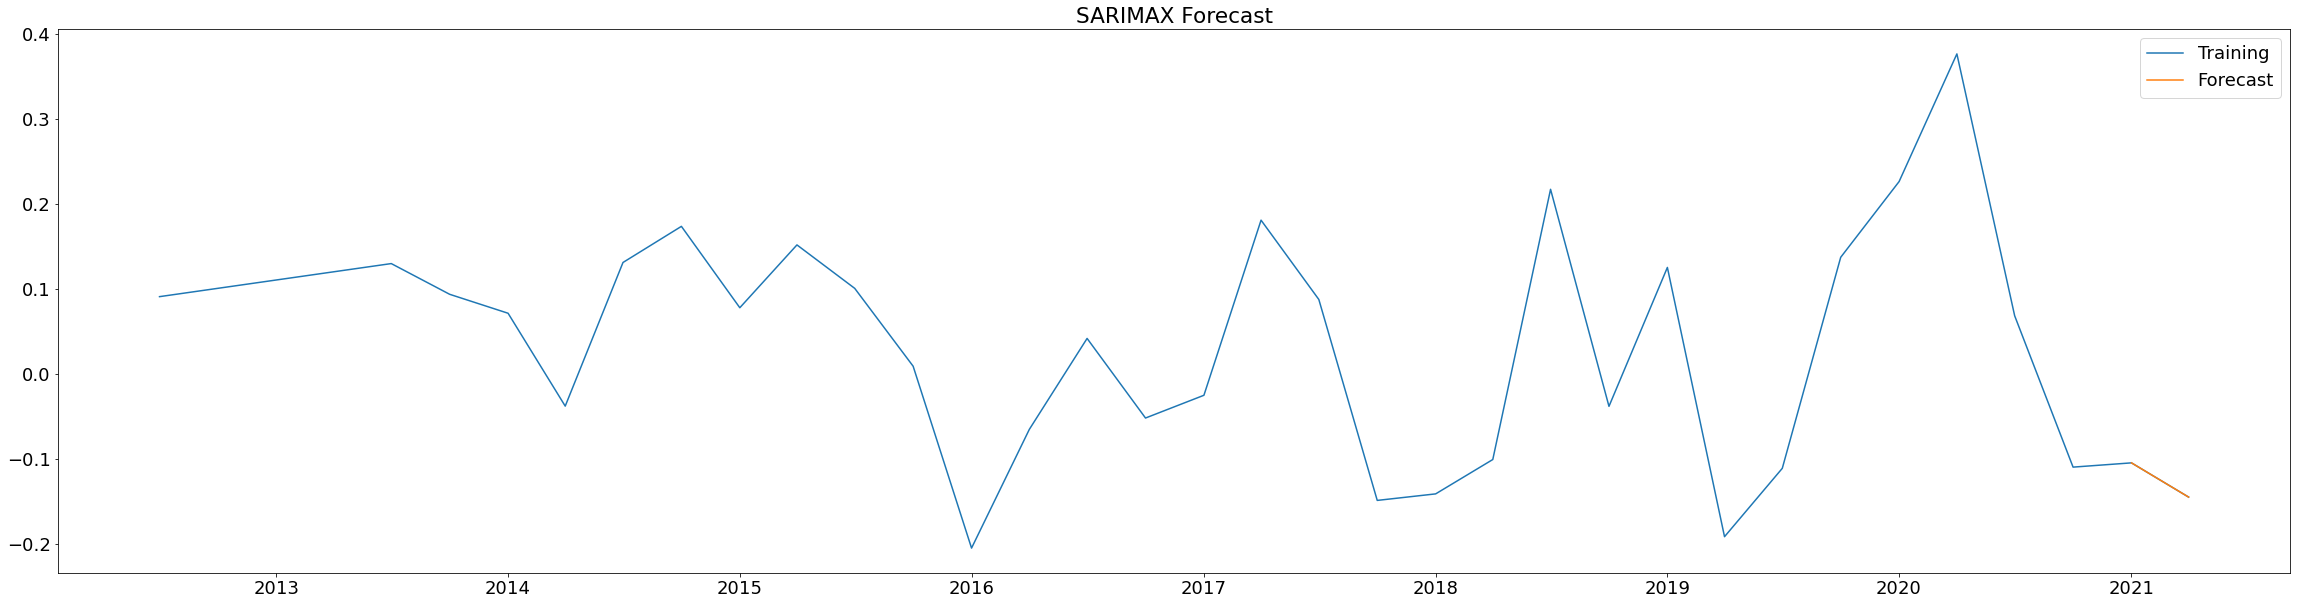

2021-04-01   -0.144985
dtype: float64


In [78]:
#Live Forecast
mod = sm.tsa.statespace.SARIMAX(y_train,X_train,order=(0,0,0),seasonal_order=(0,0,0,4))
##FIT##
results = mod.fit()
#Prediction##
train_size=len(X_train)
test_size=len(X_test)
predictions= results.predict(start=train_size, end=(train_size+test_size-1), exog=X_test)
predictions.index=X_test.index
#catch the error
#MSE.append(mse(y_test,predictions))
#Plot
plot_df = pd.concat([y_train,predictions],axis=0)
plt.title('SARIMAX Forecast')
plt.plot(plot_df, label='Training')
plt.plot(plot_df.iloc[-2:], label = 'Forecast')
plt.legend()
plt.show()
print(predictions)

In [79]:
tssq={}
tscv = TimeSeriesSplit(max_train_size=None, n_splits=5)
c=0
for train_index, test_index in (tscv.split(gr_df)):
    c+=1
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    tssq[c] = [X_train,X_test,y_train,y_test]

TRAIN: [0 1 2 3 4 5 6] TEST: [ 7  8  9 10 11]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11] TEST: [12 13 14 15 16]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16] TEST: [17 18 19 20 21]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] TEST: [22 23 24 25 26]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26] TEST: [27 28 29 30 31]


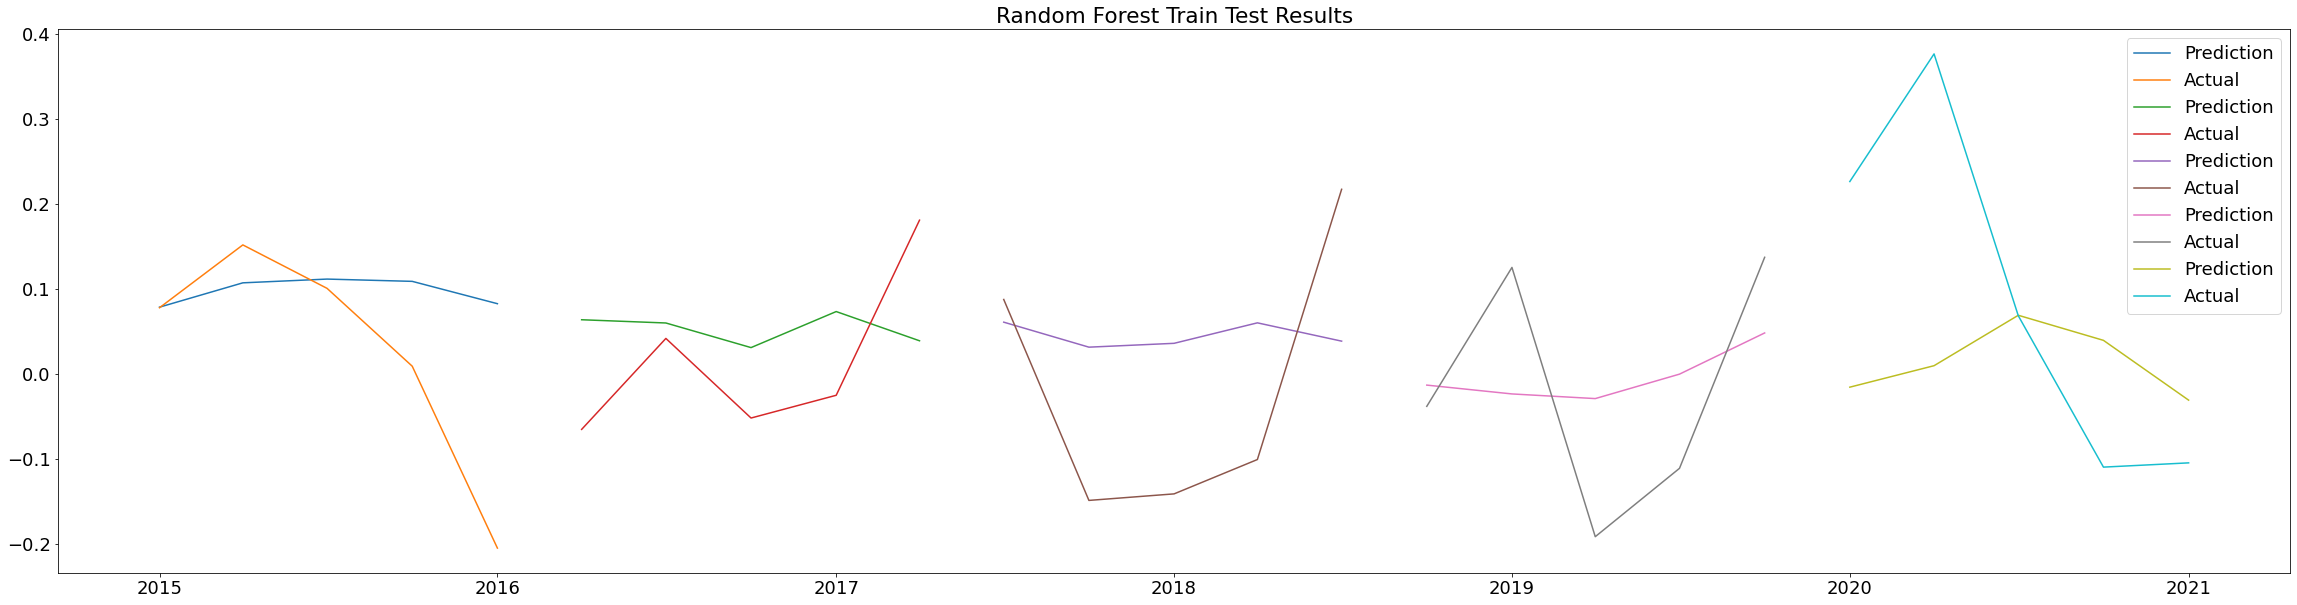

[0.018925960683352276, 0.01072048598401568, 0.024440481459954068, 0.013855791209499927, 0.044093761044351365]
The Mean Squared Error is:  0.02240729607623466


In [80]:
from sklearn.ensemble import RandomForestRegressor
MSEs=[]
for i in range(1,6):
    

    regressor = RandomForestRegressor(n_estimators=200, random_state=42)
    regressor.fit(tssq[i][0],tssq[i][2])
    pred = pd.Series(regressor.predict(tssq[i][1]),index= tssq[i][1].index)
    #catch the error
    MSEs.append(mse(tssq[i][3],pred))
    #Plot
    plt.title('Random Forest Train Test Results')
    plt.plot(pred, label='Prediction')
    plt.plot(tssq[i][3], label = 'Actual')
    plt.legend()
plt.show()



print(MSEs)
avg_MSEx = np.mean(MSEs)
print('The Mean Squared Error is: ',avg_MSEx)

In [81]:
# For live forecasting we want to train on all available data only leaving the last value as the test for the model.
X_train = gr_df.drop(['yhat'], axis=1)
X_test = Exog.T
y_train = gr_df['yhat']

In [82]:
X_test

,returns,index,spy_close,production_% Same,exports_% Same,Index.1,netIncome,ROE,ROA,operating_profit_margin,...,exports_% Reporting,exports_% Greater,bus_act_%Higher,bus_act_%Same,new_ord_%Higher,new_ord_%Same,inventory_sentiment_%TooLow,imports_%Same,Index.1,Value
2021-04-01,-0.104731,0.012337,0.075144,0.133421,0.048377,0.06097,0.198214,0.45646,0.252161,-0.026074,...,0.020494,0.039348,0.098401,-0.049371,0.209146,-0.114932,0.935982,-0.08692,0.049357,-0.032211


2021-04-01   -0.017062
dtype: float64


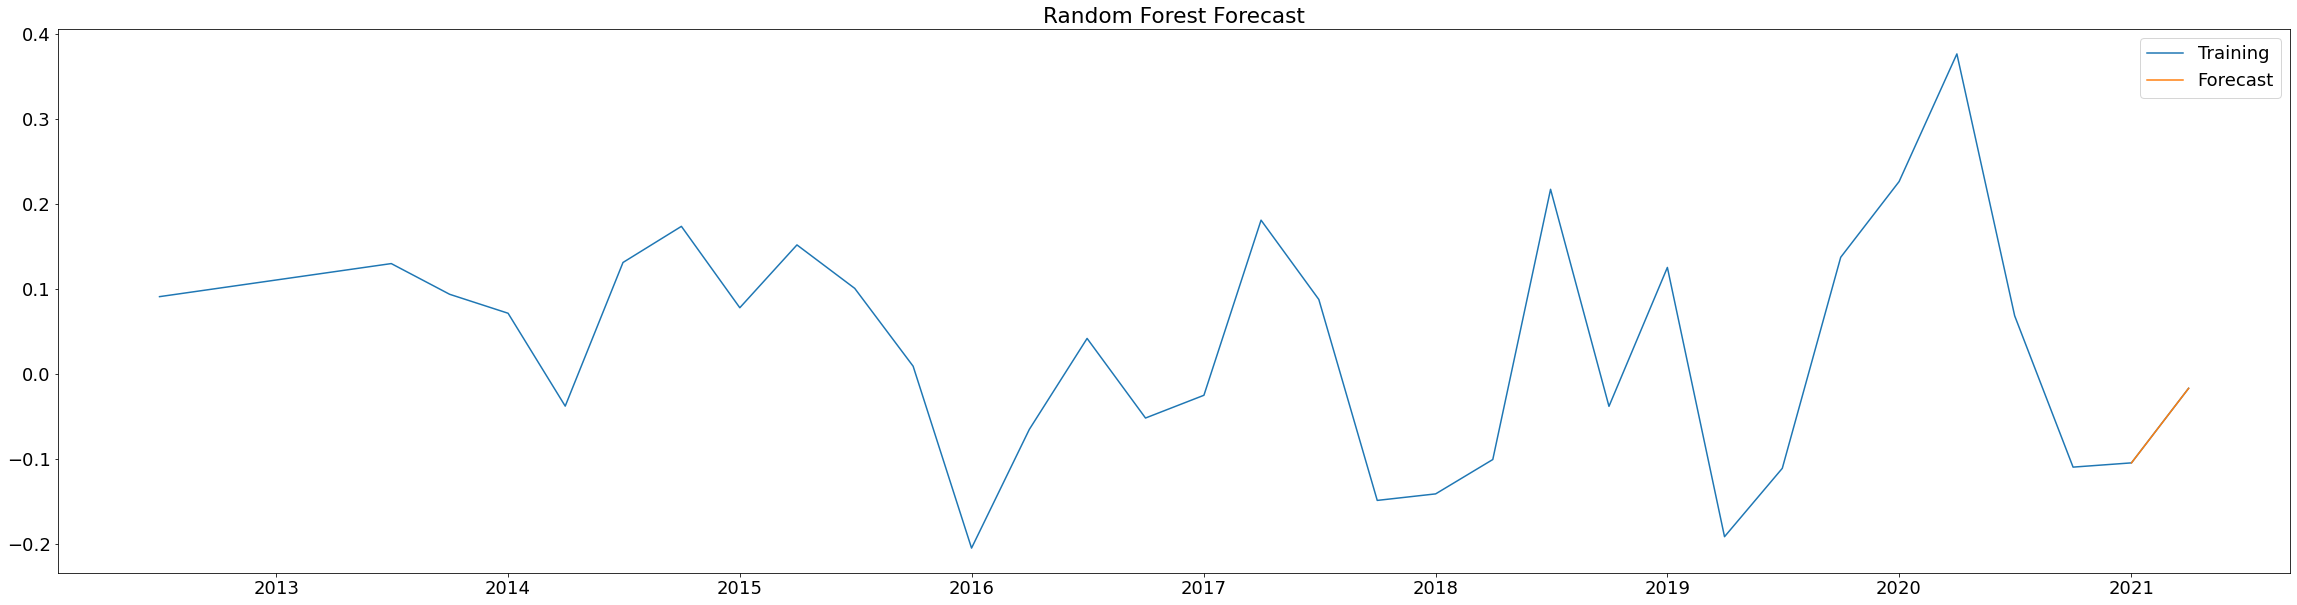

(<1x79720 sparse matrix of type '<class 'numpy.int64'>'
	with 10824 stored elements in Compressed Sparse Row format>, array([    0,    33,    74, ..., 79642, 79681, 79720], dtype=int32))


In [83]:
# Random Forest regression
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=2000, random_state=42)
regressor.fit(X_train,y_train)
pred = pd.Series(regressor.predict(X_test),index= X_test.index)
print(pred)

plot_df = pd.concat([y_train,pred],axis=0)
plt.title('Random Forest Forecast')
plt.plot(plot_df, label='Training')
plt.plot(plot_df.iloc[-2:], label = 'Forecast')
plt.legend()
plt.show()
print(regressor.decision_path(X_test))

In [84]:
#I have tested several stocks on the models to test their robustness. You can cycle through each stock to get a forecast of its quarterly returns.
# THe Live Accuracy is yet thouroughly tested. I also notice that the MSE can be decieving as -0.01 and 0.01 are not far apart but when applying actual bets to this frecast
#the inacuracy may be enough to render the model useless in making a practical trade descision. 